In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [3]:
a = pd.read_csv('data/charge_radii.csv')

In [4]:
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

In [5]:
a

,Z,symbol,N,a,radius_val,radius_unc,radius_preliminary_val,radius_preliminary_unc
0,0,n,1,1,-0.1149,0.0027,NaN,NaN
1,1,H,0,1,0.8783,0.0086,NaN,NaN
2,1,H,1,2,2.1421,0.0088,NaN,NaN
3,1,H,2,3,1.7591,0.0363,NaN,NaN
4,2,He,1,3,1.9661,0.0030,NaN,NaN
...,...,...,...,...,...,...,...,...
952,84,Po,119,203,NaN,NaN,5.5297,0.0189
953,84,Po,127,211,NaN,NaN,5.5798,0.0187
954,87,Fr,115,202,NaN,NaN,5.5505,0.0178
955,87,Fr,116,203,NaN,NaN,5.5560,0.0178


## In this notebook we do not know yet how to add the csv radius file into selected_data.h5, so for now we are going to add it by hand

In [6]:
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

## Necessary Functions

In [7]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [301]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        # selected_models_data_sets.rename(columns={models_selected[0]: 'truth'}, inplace=True)
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets.copy() #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output_list): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)
    models_output, models_output_train, models_output_validation, models_output_test = models_output_list

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                         (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                         (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, sigma_mass):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
            
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass), sigma_mass[i]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, sigma_radius):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius), sigma_radius[i]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-2]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m
    

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage
    

In [546]:
def plot_filtered_supermodel_mass(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint,title, save_fig):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -mass_std*filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = -mass_std*filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = -mass_std*filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y =- mass_std*filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    plt.title(f'{title}', fontsize = 25)
    plt.savefig(f'{save_fig}')
    plt.show()

In [545]:
def plot_filtered_supermodel_radius(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, title, save_fig):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -radius_std*filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = -radius_std*filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = -radius_std*filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = -radius_std*filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    plt.title(f'{title}', fontsize = 25)
    plt.savefig(f'{save_fig}')
    plt.show()

In [10]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full)

In [11]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [12]:
# Extracting 2 data frames that contains predictions of different properties of nuclei
selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties)

selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, a[['N', 'Z', 'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
# This dataframe will contains all the experimental data and predictions of models for radius


truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE_df[['N', 'Z', 'BE']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True)
cols_mass = list(selected_models_data_sets_mass.keys())
# The next 2 lines help you to trainsition the truth column to the start of the dataframe
print(cols_mass)
cols_mass.remove('truth')
cols_mass.insert(2, 'truth')
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]
# This dataframe will contains all the experimental data and predictions of models for binding energies

['N', 'Z', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1', 'truth']


In [13]:
selected_models_data_sets_radius

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,2.6991,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816
1,10,8,2.7726,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329
2,8,10,2.9714,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445
3,10,10,3.0055,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315
4,12,10,2.9525,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485
...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,150,94,5.8948,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415
345,146,96,5.8285,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126
346,148,96,5.8429,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104
347,150,96,5.8562,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470


In [14]:
selected_models_data_sets_mass

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,127.619315,126.738,129.026,127.455,128.114,128.856436,128.904993,129.839429,127.368236,126.708495,121.705460
1,10,8,139.807766,140.156,141.992,141.423,141.715,144.746257,144.484846,144.734392,141.963546,142.040342,136.123181
2,12,8,151.371414,151.224,152.793,153.215,153.432,158.460613,156.849135,156.488630,153.746333,154.121072,147.620242
3,14,8,162.027188,160.513,161.884,163.303,163.311,170.486446,167.278899,166.483309,163.855872,164.192707,157.219361
4,16,8,168.952452,167.472,168.465,170.768,170.970,178.908577,174.420231,173.303716,170.930478,171.196394,163.998623
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,1909.066432,1910.765,1907.813,1909.928,1914.193,1894.445901,1900.875946,1898.639172,1902.293050,1907.479821,1908.851310
625,156,106,1923.387483,1925.019,1921.738,1924.361,1928.042,1909.221132,1915.371887,1912.434046,1916.575965,1921.884406,1922.815073
626,156,108,1926.771317,1928.415,1925.436,1927.488,1932.395,1911.680941,1918.341803,1916.133844,1919.723353,1925.454882,1926.206982
627,158,108,1941.337453,1943.010,1939.691,1942.276,1946.498,1927.231556,1933.157370,1930.669126,1934.554087,1940.259078,1940.812152


In [15]:
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

In [16]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

In [17]:
filtered_NZ_df_mass = selected_models_data_sets_mass[['N', 'Z']]
filtered_NZ_mass = np.array(filtered_NZ_df_mass)
Full_set_mass = filtered_NZ_mass.copy()

In [135]:
# This will help you to scale our dataframe so that it can become unitless
mass_std = np.std(selected_models_data_sets_mass['truth'])
selected_models_data_sets_mass_scaled = selected_models_data_sets_mass.copy()
predictions_name_list = selected_models_data_sets_mass_scaled.columns[2:]
selected_models_data_sets_mass_scaled[predictions_name_list] = selected_models_data_sets_mass_scaled[predictions_name_list]/mass_std

radius_std = np.std(selected_models_data_sets_radius['truth'])
selected_models_data_sets_radius_scaled = selected_models_data_sets_radius.copy()
predictions_name_list = selected_models_data_sets_radius_scaled.columns[2:]
selected_models_data_sets_radius_scaled[predictions_name_list] = selected_models_data_sets_radius_scaled[predictions_name_list]/radius_std

In [156]:
mass_std

472.96503409748556

In [136]:
selected_models_data_sets_mass_scaled

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,0.269828,0.267965,0.272802,0.269481,0.270874,0.272444,0.272547,0.274522,0.269297,0.267902,0.257324
1,10,8,0.295599,0.296335,0.300217,0.299014,0.299631,0.306040,0.305487,0.306015,0.300157,0.300319,0.287808
2,12,8,0.320048,0.319736,0.323053,0.323946,0.324405,0.335037,0.331629,0.330867,0.325069,0.325861,0.312117
3,14,8,0.342578,0.339376,0.342275,0.345275,0.345292,0.360463,0.353681,0.351999,0.346444,0.347156,0.332412
4,16,8,0.357220,0.354090,0.356189,0.361058,0.361485,0.378270,0.368780,0.366420,0.361402,0.361964,0.346746
...,...,...,...,...,...,...,...,...,...,...,...,...,...
624,154,106,4.036380,4.039971,4.033729,4.038201,4.047219,4.005467,4.019062,4.014333,4.022059,4.033025,4.035925
625,156,106,4.066659,4.070108,4.063171,4.068717,4.076500,4.036707,4.049711,4.043500,4.052257,4.063481,4.065449
626,156,108,4.073813,4.077289,4.070990,4.075329,4.085704,4.041908,4.055991,4.051322,4.058912,4.071030,4.072620
627,158,108,4.104611,4.108147,4.101130,4.106595,4.115522,4.074787,4.087316,4.082055,4.090269,4.102331,4.103500


In [137]:
selected_models_data_sets_radius_scaled

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,8,8,3.795166,3.837208,3.783777,3.862518,3.845645,3.928889,3.970802,3.931124,3.961481,3.927966,3.924127
1,10,8,3.898514,3.842833,3.802056,3.865330,3.835802,3.928230,3.972305,3.935738,3.948088,3.915970,3.910787
2,8,10,4.178044,4.156390,4.094522,4.140923,4.154984,4.156654,4.200666,4.168073,4.206746,4.170583,4.180919
3,10,10,4.225991,4.198572,4.136705,4.183105,4.180293,4.137416,4.180357,4.150729,4.182838,4.127794,4.172300
4,12,10,4.151469,4.162014,4.146547,4.187324,4.135299,4.167837,4.179074,4.185795,4.192028,4.112812,4.173945
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,150,94,8.288595,8.342307,8.324028,8.338089,8.354962,8.310053,8.322027,8.317345,8.299620,8.308024,8.328830
341,146,96,8.195371,8.345120,8.325434,8.342307,8.346526,8.323292,8.335429,8.330193,8.308312,8.312735,8.335454
342,148,96,8.215619,8.363399,8.349338,8.361993,8.367617,8.337898,8.350833,8.344702,8.324310,8.329529,8.352296
343,150,96,8.234320,8.377460,8.359180,8.374647,8.385896,8.350942,8.365134,8.358697,8.339395,8.345346,8.368278


In [138]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [139]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

In [140]:
test_coordinates_mass.shape

(258,)

In [141]:
train_coordinates_radius.shape

(167,)

In [22]:
# After having separated our data points into intrapolation and extrapolation part, first we have to extract all the model predictions and perform
# PCA on that data set

In [239]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass_scaled, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius_scaled, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [240]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [241]:
models_output_mass_train

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
0,8,8,16,0.267965,0.272802,0.269481,0.270874,0.272444,0.272547,0.274522,0.269297,0.267902,0.257324,0.269828
1,10,8,18,0.296335,0.300217,0.299014,0.299631,0.306040,0.305487,0.306015,0.300157,0.300319,0.287808,0.295599
2,12,8,20,0.319736,0.323053,0.323946,0.324405,0.335037,0.331629,0.330867,0.325069,0.325861,0.312117,0.320048
6,8,10,18,0.279581,0.283167,0.282279,0.283473,0.290685,0.290019,0.290691,0.284763,0.286816,0.273454,0.279392
7,10,10,20,0.328487,0.333972,0.330646,0.329426,0.337493,0.337338,0.337510,0.332496,0.334901,0.323351,0.339655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,144,92,236,3.781195,3.778804,3.784595,3.783529,3.768504,3.773660,3.763102,3.774529,3.783561,3.782985,3.785503
584,146,92,238,3.803996,3.802180,3.808444,3.806353,3.793735,3.797409,3.785411,3.798200,3.807324,3.806170,3.809351
585,148,92,240,3.826283,3.824902,3.831594,3.828165,3.817421,3.819687,3.806260,3.820442,3.829579,3.828023,3.832048
590,142,94,236,3.780561,3.775228,3.781833,3.783798,3.758656,3.768041,3.760223,3.769575,3.779139,3.780128,3.781229


In [242]:
filtered_models_output_mass_list_50 = filtered_models_output(50, models_output_mass_list)
filtered_models_output_radius_list_20 = filtered_models_output(20, models_output_radius_list)

In [243]:
filtered_models_output_mass_50 = filtered_models_output_mass_list_50[0]
filtered_models_output_mass_train_50 = filtered_models_output_mass_list_50[1]
filtered_models_output_mass_validation_50 = filtered_models_output_mass_list_50[2]
filtered_models_output_mass_test_50 = filtered_models_output_mass_list_50[3]
filtered_models_output_mass_stable_50 = filtered_models_output_mass_list_50[4]

filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_models_output_radius_train_20 = filtered_models_output_radius_list_20[1]
filtered_models_output_radius_validation_20 = filtered_models_output_radius_list_20[2]
filtered_models_output_radius_test_20 = filtered_models_output_radius_list_20[3]
filtered_models_output_radius_stable_20 = filtered_models_output_radius_list_20[4]

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

In [244]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(167,1)
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(334,1)
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

[7.53102724e-01 3.82457788e-01 2.93421363e-01 2.31793834e-01
 1.59317124e-01 1.35416551e-01 1.15742661e-01 1.04203963e-01
 9.71432110e-02 2.95196079e-14]


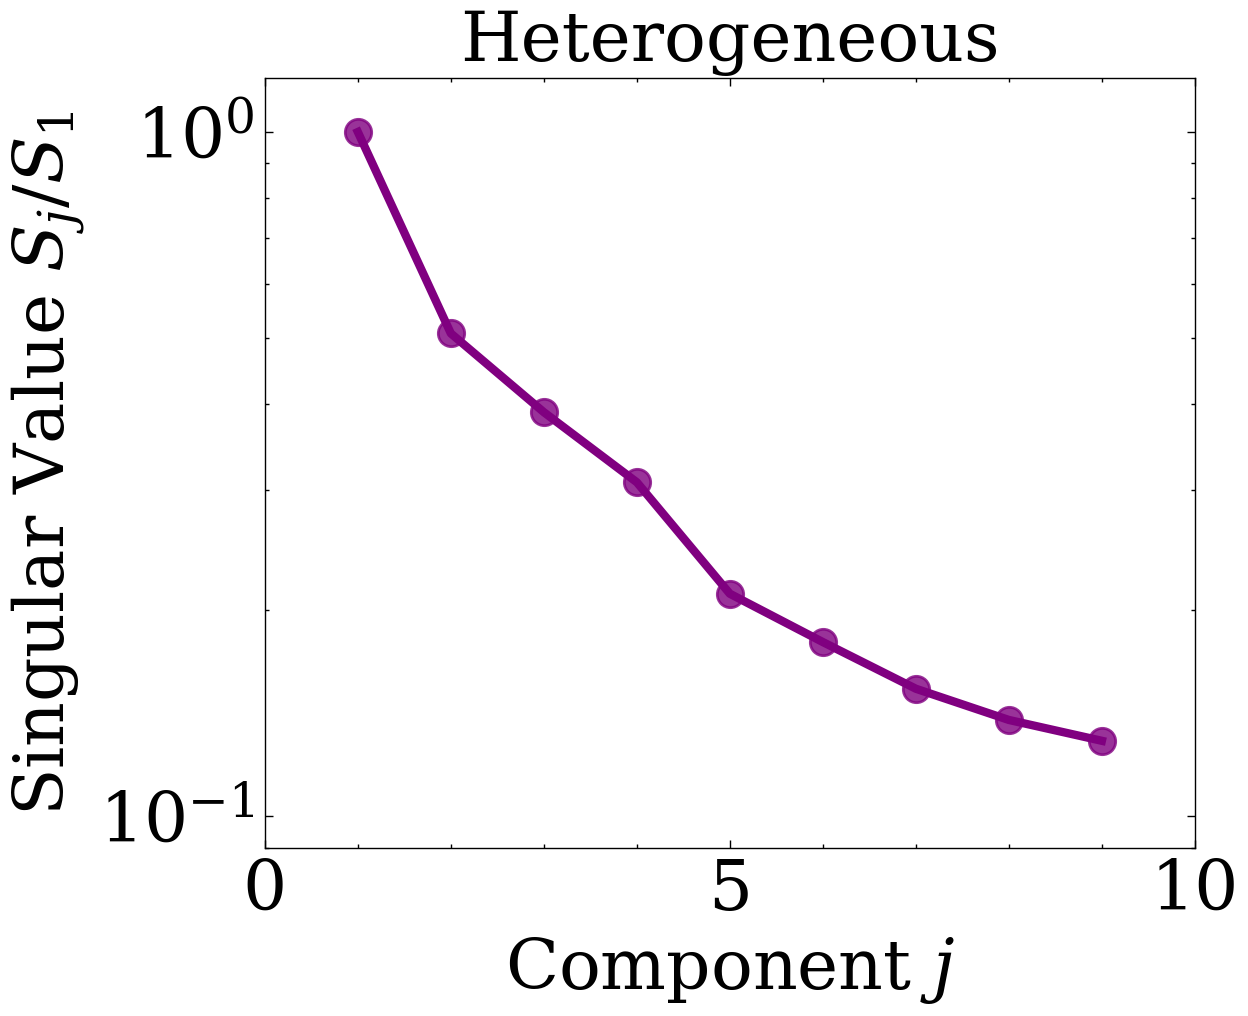

In [534]:
U, S, Vt = np.linalg.svd(model_predictions_combined_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,5,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.ylim((0.09,1.2))
plt.title('Heterogeneous', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Singular Values - Heterogeneous Calibration.png')
plt.show()

In [29]:
# def PC_RMSE_calculator_mass(components_kept, predictions_mean_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

#     predictions_mean = predictions_mean_list[0]
#     predictions_mean_train = predictions_mean_list[1]
#     predictions_mean_validation = predictions_mean_list[2]
#     predictions_mean_test = predictions_mean_list[3]

#     # models_output = models_output_list[0]
#     # models_output_train = models_output_list[1]
#     # models_output_validation = models_output_list[2]
#     # models_output_test = models_output_list[3]

#     model_predictions = model_predictions_list[0]
#     model_predictions_train = model_predictions_list[1]
#     model_predictions_validation = model_predictions_list[2]
#     model_predictions_test = model_predictions_list[3]

#     S_hat=np.array([S[i] for i in range(components_kept)])

#     # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
#     U_hat=np.array([U.T[i] for i in range(components_kept)])

#     # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
#     Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


#     if centering_data:
#         num_components=components_kept+1
#     else:
#         num_components=components_kept



#     #########################################
#     #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
#     models_PC_train = {}
#     if centering_data:
#         models_PC_train[str("PC_0")] = predictions_mean_train       
#     for i in range(components_kept):
#         models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
#     # models_PC_train["N"] = models_output_train["N"]
#     # models_PC_train["Z"] = models_output_train["Z"]
#     # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
#     # models_PC_training = pd.DataFrame(models_PC_train)
#     models_PC_train = pd.DataFrame(models_PC_train)
#     #########################################

#     #########################################
#     #Creating principal components that are for validation
#     models_PC_validation = {}
#     if centering_data:
#         models_PC_validation[str("PC_0")] = predictions_mean_validation
#     for i in range(components_kept):
#         models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
#     # models_PC_validation["N"] = models_output_validation["N"]
#     # models_PC_validation["Z"] = models_output_validation["Z"]
#     # models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
#     models_PC_validation = pd.DataFrame(models_PC_validation)
#     #########################################

#     #########################################
#     #Creating principal components that are for testing
#     models_PC_testing = {}
#     if centering_data:
#         models_PC_testing[str("PC_0")] = predictions_mean_test
#     for i in range(components_kept):
#         # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
#         models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

#     # models_PC_testing["N"] = models_output_test["N"]
#     # models_PC_testing["Z"] = models_output_test["Z"]
#     # models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
#     models_PC_testing = pd.DataFrame(models_PC_testing)
#     #########################################

#     #Creating principal components that are valid everywhere (testing + training + validation)
#     models_PC = {}
#     if centering_data:
#         models_PC[str("PC_0")] = predictions_mean
#     for i in range(components_kept):
#         models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
#     models_PC = pd.DataFrame(models_PC)
#     # models_PC["N"] = Full_set.T[0]
#     # models_PC["Z"] = Full_set.T[1]
#     # models_PC["A"] = models_PC["N"] + models_PC["Z"]
#     #########################################

#     key_list_PCs=list(models_PC_testing.keys())

#     real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
#     X=np.copy(U_hat)
#     if centering_data:
#         y=np.copy(real_data)-predictions_mean_train
#     else:
#         y=np.copy(models_output_train["truth"].tolist())
#     #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
#     X_train=[]
#     for i in range(num_components):
#         X_train.append(models_PC_train[key_list_PCs[i]].tolist())
#     X_train=np.array(X_train)
#     #Making the list of principal components across the validation part
#     X_validation=[]
#     for i in range(num_components):
#         X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
#     X_validation=np.array(X_validation)

#     #Making the list of principal components across the testing part
#     X_test=[]
#     for i in range(num_components):
#         X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
#     X_test=np.array(X_test)
#     #Making the list of principal components across the entire chart (training+validation+testing)
#     X_full=[]
#     for i in range(num_components):
#         X_full.append(models_PC[key_list_PCs[i]].tolist())
#     X_full=np.array(X_full)

#     X_train_centered = X_train[1:,:]

#     # 1) Find the least square solution for the training part
#     X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
#     beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
#     #1.5) Construct the super model across the entire range and the test range
#     if centering_data:
#         beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
#     else:
#         beta_full=np.copy(beta)

#     # supermodel=X.T.dot(beta_full)
#     supermodel=X_train[:,:300].T.dot(beta_full)
#     supermodel_train=np.copy(supermodel)
#     supermodel_validation=X_validation[:,:71].T.dot(beta_full)
#     supermodel_test=X_test[:,:258].T.dot(beta_full)
#     supermodel_full=X_full[:,:629].T.dot(beta_full)

    
#     super_model_residuals_train=supermodel_train-models_output_mass_train['truth'][:300].tolist()
#     super_model_residuals_validation= supermodel_validation-models_output_mass_validation['truth'][:71].tolist()
#     super_model_residuals_test = supermodel_test-models_output_mass_test['truth'][:258].tolist()
#     super_model_residuals_full = supermodel_full-models_output_mass['truth'][:629].tolist()

#     sigma_train=np.sqrt(np.sum(super_model_residuals_train**2) / len(super_model_residuals_train) )
#     sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
#     sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
#     sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


#     return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [30]:
# def PC_RMSE_calculator_radius(components_kept, predictions_mean_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

#     predictions_mean = predictions_mean_list[0]
#     predictions_mean_train = predictions_mean_list[1]
#     predictions_mean_validation = predictions_mean_list[2]
#     predictions_mean_test = predictions_mean_list[3]

#     # models_output = models_output_list[0]
#     # models_output_train = models_output_list[1]
#     # models_output_validation = models_output_list[2]
#     # models_output_test = models_output_list[3]

#     model_predictions = model_predictions_list[0]
#     model_predictions_train = model_predictions_list[1]
#     model_predictions_validation = model_predictions_list[2]
#     model_predictions_test = model_predictions_list[3]

#     S_hat=np.array([S[i] for i in range(components_kept)])

#     # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
#     U_hat=np.array([U.T[i] for i in range(components_kept)])

#     # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
#     Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


#     if centering_data:
#         num_components=components_kept+1
#     else:
#         num_components=components_kept



#     #########################################
#     #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
#     models_PC_train = {}
#     if centering_data:
#         models_PC_train[str("PC_0")] = predictions_mean_train       
#     for i in range(components_kept):
#         models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
#     # models_PC_train["N"] = models_output_train["N"]
#     # models_PC_train["Z"] = models_output_train["Z"]
#     # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
#     # models_PC_training = pd.DataFrame(models_PC_train)
#     models_PC_train = pd.DataFrame(models_PC_train)
#     #########################################

#     #########################################
#     #Creating principal components that are for validation
#     models_PC_validation = {}
#     if centering_data:
#         models_PC_validation[str("PC_0")] = predictions_mean_validation
#     for i in range(components_kept):
#         models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
#     # models_PC_validation["N"] = models_output_validation["N"]
#     # models_PC_validation["Z"] = models_output_validation["Z"]
#     # models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
#     models_PC_validation = pd.DataFrame(models_PC_validation)
#     #########################################

#     #########################################
#     #Creating principal components that are for testing
#     models_PC_testing = {}
#     if centering_data:
#         models_PC_testing[str("PC_0")] = predictions_mean_test
#     for i in range(components_kept):
#         # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
#         models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

#     # models_PC_testing["N"] = models_output_test["N"]
#     # models_PC_testing["Z"] = models_output_test["Z"]
#     # models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
#     models_PC_testing = pd.DataFrame(models_PC_testing)
#     #########################################

#     #Creating principal components that are valid everywhere (testing + training + validation)
#     models_PC = {}
#     if centering_data:
#         models_PC[str("PC_0")] = predictions_mean
#     for i in range(components_kept):
#         models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
#     models_PC = pd.DataFrame(models_PC)
#     # models_PC["N"] = Full_set.T[0]
#     # models_PC["Z"] = Full_set.T[1]
#     # models_PC["A"] = models_PC["N"] + models_PC["Z"]
#     #########################################

#     key_list_PCs=list(models_PC_testing.keys())

#     real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
#     X=np.copy(U_hat)
#     if centering_data:
#         y=np.copy(real_data)-predictions_mean_train
#     else:
#         y=np.copy(models_output_train["truth"].tolist())
#     #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
#     X_train=[]
#     for i in range(num_components):
#         X_train.append(models_PC_train[key_list_PCs[i]].tolist())
#     X_train=np.array(X_train)
#     #Making the list of principal components across the validation part
#     X_validation=[]
#     for i in range(num_components):
#         X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
#     X_validation=np.array(X_validation)

#     #Making the list of principal components across the testing part
#     X_test=[]
#     for i in range(num_components):
#         X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
#     X_test=np.array(X_test)
#     #Making the list of principal components across the entire chart (training+validation+testing)
#     X_full=[]
#     for i in range(num_components):
#         X_full.append(models_PC[key_list_PCs[i]].tolist())
#     X_full=np.array(X_full)

#     X_train_centered = X_train[1:,:]

#     # 1) Find the least square solution for the training part
#     X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
#     beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
#     #1.5) Construct the super model across the entire range and the test range
#     if centering_data:
#         beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
#     else:
#         beta_full=np.copy(beta)

#     # supermodel=X.T.dot(beta_full)
#     supermodel=X_train[:,300:].T.dot(beta_full)
#     supermodel_train=np.copy(supermodel)
#     supermodel_validation=X_validation[:,71:].T.dot(beta_full)
#     supermodel_test=X_test[:,258:].T.dot(beta_full)
#     supermodel_full=X_full[:,629:].T.dot(beta_full)

    
#     super_model_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
#     super_model_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
#     super_model_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
#     super_model_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

#     sigma_train=np.sqrt(np.sum(super_model_residuals_train**2) / len(super_model_residuals_train) )
#     sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
#     sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
#     sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


#     return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [159]:
def PC_RMSE_calculator_mass(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_combined_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_combined_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(real_data)-predictions_mean_combined_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_mass_train.T)
    supermodel_validation = model_weights.dot(model_predictions_mass_validation.T)
    supermodel_test = model_weights.dot(model_predictions_mass_test.T)
    supermodel_full = model_weights.dot(model_predictions_mass.T)
    
    supermodel_residuals_train=supermodel_train-models_output_mass_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_mass_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_mass_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_mass['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [160]:
def PC_RMSE_calculator_radius(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_combined_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_combined_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(real_data)-predictions_mean_combined_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_radius_train.T)
    supermodel_validation = model_weights.dot(model_predictions_radius_validation.T)
    supermodel_test = model_weights.dot(model_predictions_radius_test.T)
    supermodel_full = model_weights.dot(model_predictions_radius.T)
    
    supermodel_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [33]:
predictions_mean_combined_list = [predictions_mean_combined, predictions_mean_combined_train, predictions_mean_combined_validation, predictions_mean_combined_test]
# models_output_combined_list = models_output_combined_list
model_predictions_combined_list = [model_predictions_combined, model_predictions_combined_train, model_predictions_combined_validation, model_predictions_combined_test]

In [170]:
centering_data = True
if centering_data:
    s_mass_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_mass_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_mass_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_mass_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_mass(i)
        s_mass_train.append(res[0])
        s_mass_validation.append(res[1])
        s_mass_test.append(res[2])
        
        s_mass_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

In [171]:
centering_data = True
if centering_data:
    s_radius_validation= [np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_radius(i)
        s_radius_train.append(res[0] )
        s_radius_validation.append(res[1])
        s_radius_test.append(res[2] )
        
        s_radius_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

In [172]:
s_mass_train = mass_std * np.array(s_mass_train)
s_mass_validation = mass_std * np.array(s_mass_validation)
s_mass_test = mass_std * np.array(s_mass_test)
s_mass_all = mass_std * np.array(s_mass_all)

s_radius_train = radius_std * np.array(s_radius_train)
s_radius_validation = radius_std * np.array(s_radius_validation)
s_radius_test = radius_std * np.array(s_radius_test)
s_radius_all = radius_std * np.array(s_radius_all)

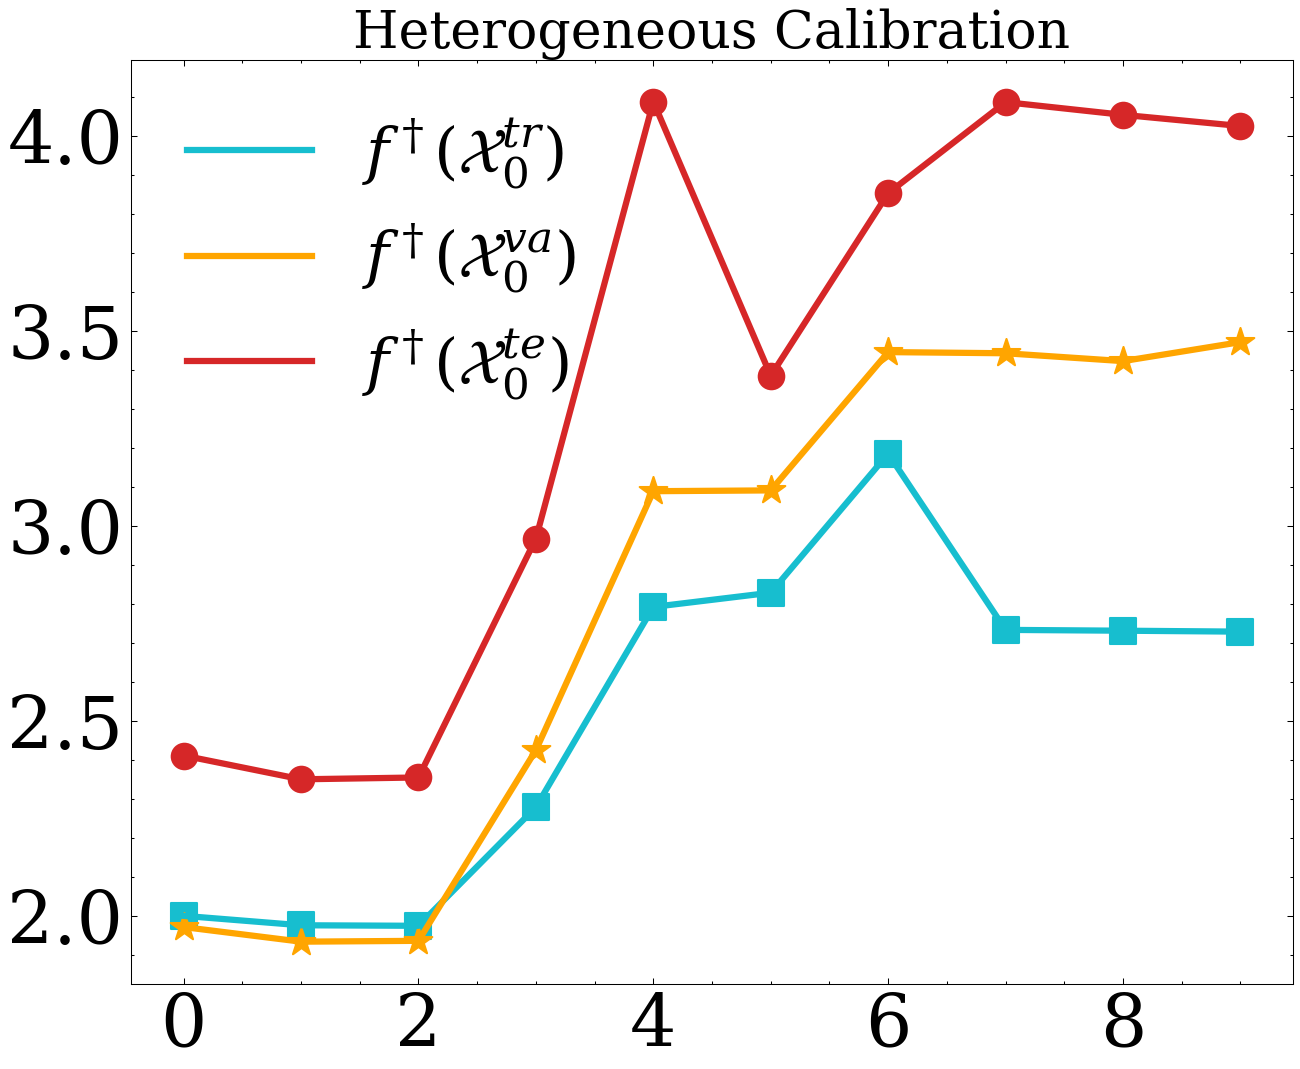

In [535]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Heterogeneous Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Mass RMSE decay - Heterogeneous Analysis.png')
plt.legend(fontsize=30)
plt.show()

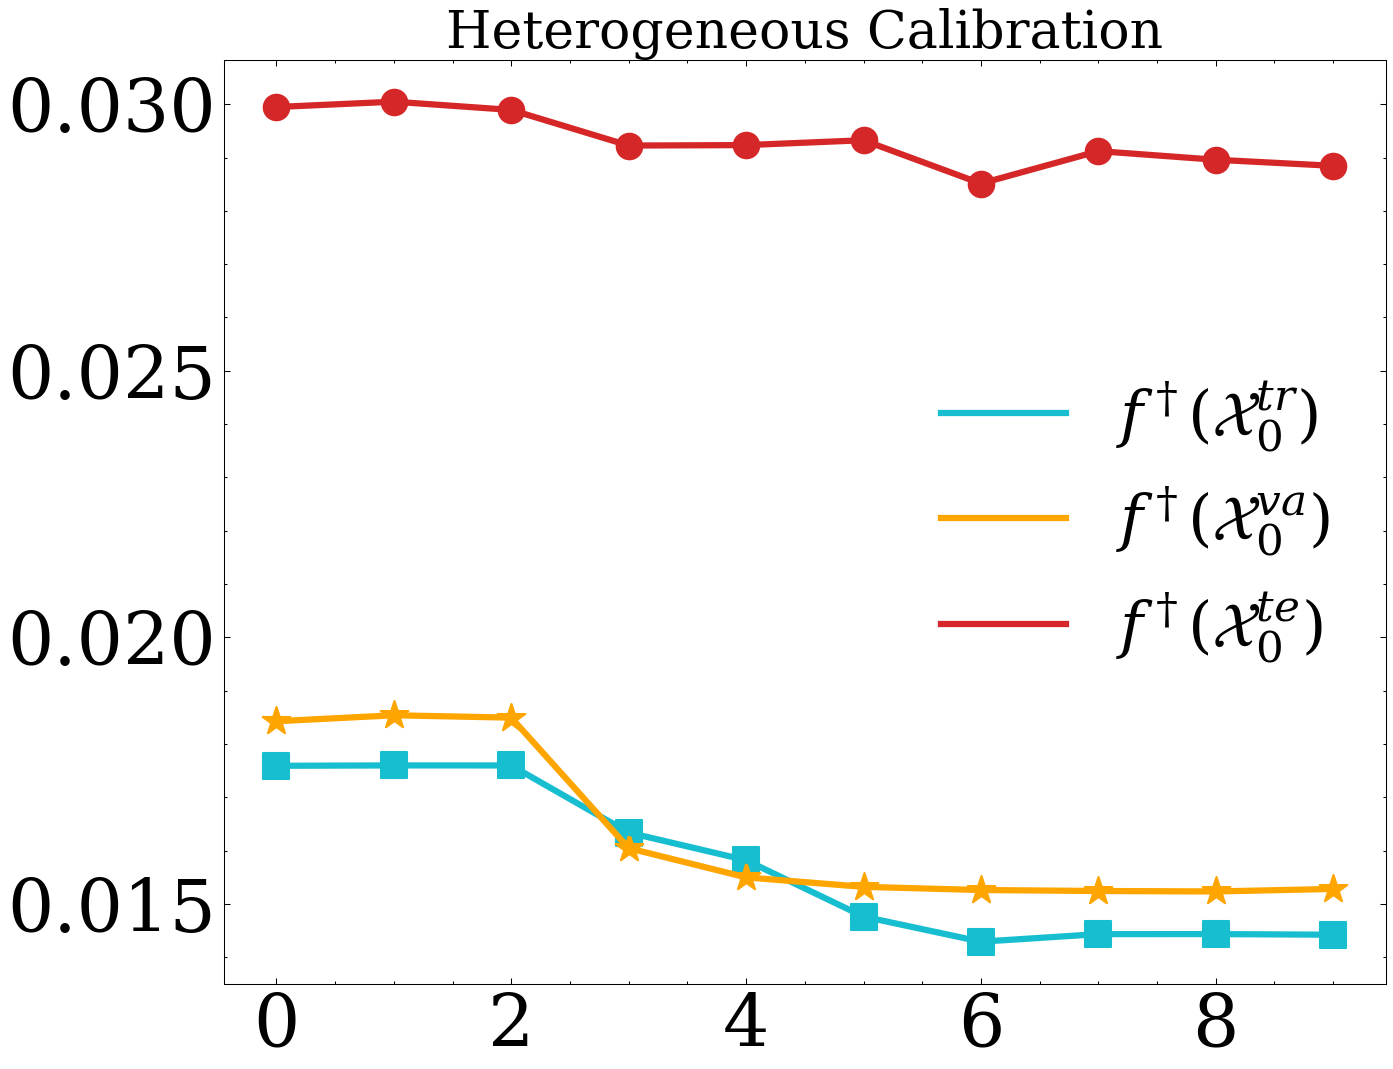

In [536]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Heterogeneous Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Heterogeneous Analysis.png')
plt.legend(fontsize=30)
plt.show()

In [174]:
components_kept = 2
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized = np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [175]:
models_PC_combined = models_PC_output(Vt_hat, model_predictions_combined, predictions_mean_combined)
models_PC_combined_train = models_PC_output(Vt_hat, model_predictions_combined_train, predictions_mean_combined_train)
models_PC_combined_validation = models_PC_output(Vt_hat, model_predictions_combined_validation, predictions_mean_combined_validation)
models_PC_combined_test = models_PC_output(Vt_hat, model_predictions_combined_test, predictions_mean_combined_test)

In [176]:
np.dot(Vt_hat[0], model_predictions_combined_train.T)[0]

-0.004187316061983413

In [177]:
models_PC_combined_train

,PC_0,PC_1,PC_2
0,0.269516,-0.004187,-0.011475
1,0.300102,-0.011238,-0.005450
2,0.325172,-0.015387,-0.002095
3,0.284493,-0.013196,0.000762
4,0.332562,-0.010557,0.000592
...,...,...,...
462,7.752922,-0.020308,-0.039906
463,8.132629,-0.001563,-0.084093
464,8.156284,0.006331,-0.095098
465,8.204898,-0.024135,-0.077247


### The first plots we are going to show is the plots of projections of models onto the PCs. We will compare this graph between the 3 cases to see if there is any discrepancies between the 3 analysis

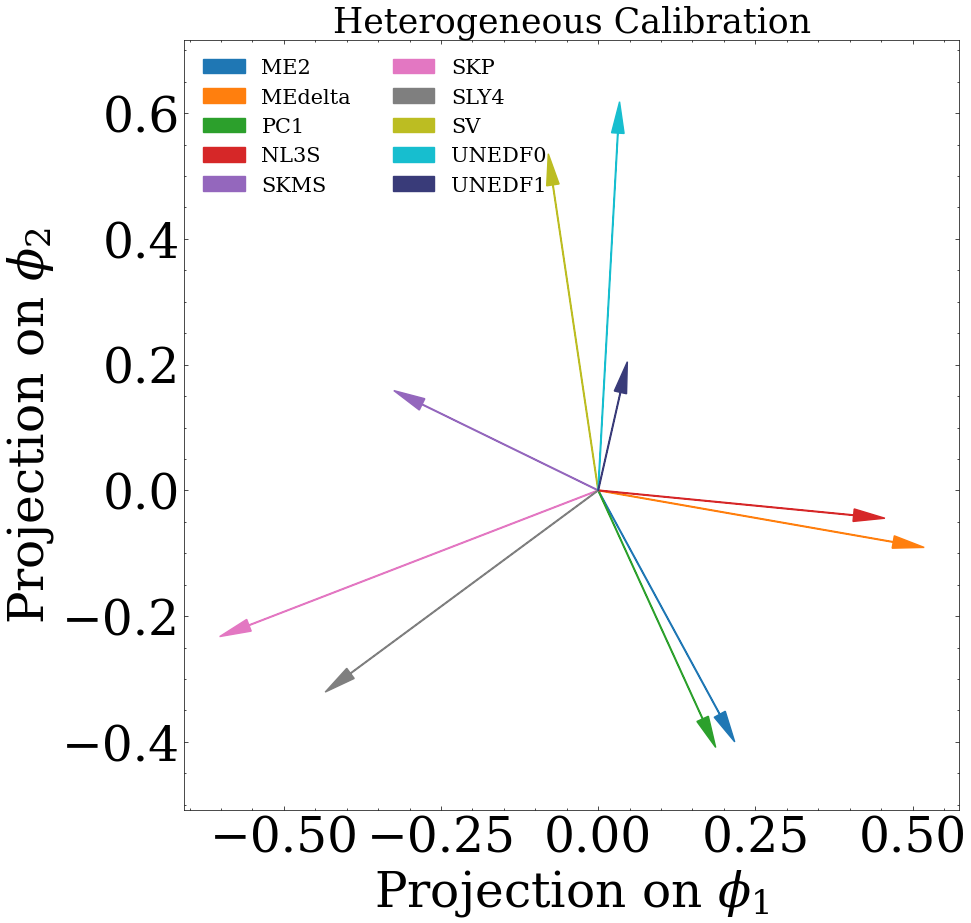

In [538]:

plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,10), dpi=100)


visited_model=0
for model in key_list:
    ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
            head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=model)
#     plt.text(Vt_hat_normalized.T[visited_model][0], Vt_hat_normalized.T[visited_model][1], model,fontsize=20,ha='center', va='center')    
    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #     head_width=0.02, head_length=0.05, fc='w', ec='w',label=model)

    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #         head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=str(visited_model))

    visited_model=visited_model+1



plt.xlabel('Projection on $\phi_1$',fontsize=35)
plt.ylabel('Projection on $\phi_2$',fontsize=35)

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)


plt.legend(fontsize=15,ncols=2)
# ax.set_xticks([-0.2,0,0.2,0.4,0.6])
plt.axis('equal')
# plt.xlim(-0.25, 0.6)
# plt.ylim(-0.43, 0.5)
plt.title('Heterogeneous Calibration', fontsize = 25)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/PCs projections/Projections on PCs - Heterogeneous Analysis.png')
plt.show()


In [179]:
X = np.copy(U_hat)

y_mass = models_output_mass_train['truth'] - predictions_mean_mass_train
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train
y = np.hstack((y_mass,y_radius))

X_train = models_PC_combined_train.values
X_validation = models_PC_combined_validation.values
X_test = models_PC_combined_test.values
X_full = models_PC_combined.values

In [180]:
X.shape

(467, 2)

## Let's consider both unconstrained and complex case

### Unconstrained

In [468]:
nu0_mass_chosen = 1
sigma20_mass_chosen = 0.5/mass_std

nu0_radius_chosen = 1
sigma20_radius_chosen = 0.05/radius_std

In [469]:
def gibbs_sampler(y, X, iterations, prior_info_mass, prior_info_radius):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0_mass, sigma20_mass  =  prior_info_mass
    nu0_radius, sigma20_radius = prior_info_radius
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)

    y_mass = y[:300] 
    y_radius = y[300:] 
    X_mass = X[:300,:]
    X_radius = X[300:,:]
    
    X_T_X_mass=X_mass.T.dot(X_mass)
    X_T_X_mass_inv = np.linalg.inv(X_T_X_mass)

    X_T_X_radius=X_radius.T.dot(X_radius)
    X_T_X_radius_inv = np.linalg.inv(X_T_X_radius)
    
    n = len(y_mass)
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2_mass = np.sum(residuals**2) / len(residuals) 
    sigma2_radius = np.sum(residuals**2) / len(residuals) 
    # cov_matrix = sigma2 * X_T_X_inv

    samples_beta = []
    samples_sigma2_mass = []
    samples_sigma2_radius = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X_mass/sigma2_mass + X_T_X_radius/sigma2_radius
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(   b_mean_cov_inv.dot(b_mean_prior)+ X_mass.T.dot(y_mass)/sigma2_mass + X_radius.T.dot(y_radius)/sigma2_radius  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel_mass=X_mass.dot(b_current)
        
        residuals_mass = y_mass - supermodel_mass

        supermodel_radius=X_radius.dot(b_current)
        
        residuals_radius = y_radius - supermodel_radius
        
        
        shape_post_mass = (nu0_mass + n)/2.
        shape_post_radius = (nu0_radius + n)/2
        
        scale_post_mass = (nu0_mass*sigma20_mass + np.sum(residuals_mass**2))/2.0
        scale_post_radius = (nu0_radius*sigma20_radius + np.sum(residuals_radius**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post_mass, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post_radius, 1/scale_post_radius)
        
        samples_beta.append(b_current)
        samples_sigma2_mass.append(sigma2_mass)
        samples_sigma2_radius.append(sigma2_radius)

    
    samples_beta = np.array(samples_beta)
    samples_sigma2_mass = np.array(samples_sigma2_mass).reshape(iterations,1)
    samples_sigma2_radius = np.array(samples_sigma2_radius).reshape(iterations,1)

    samples = np.hstack((samples_beta, np.sqrt(samples_sigma2_mass), np.sqrt(samples_sigma2_radius)))
    
    return samples

In [470]:
%%time
samples = gibbs_sampler(y,X, 100000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_mass_chosen, sigma20_mass_chosen], [nu0_radius_chosen, sigma20_radius_chosen])

CPU times: total: 17.6 s
Wall time: 16.4 s


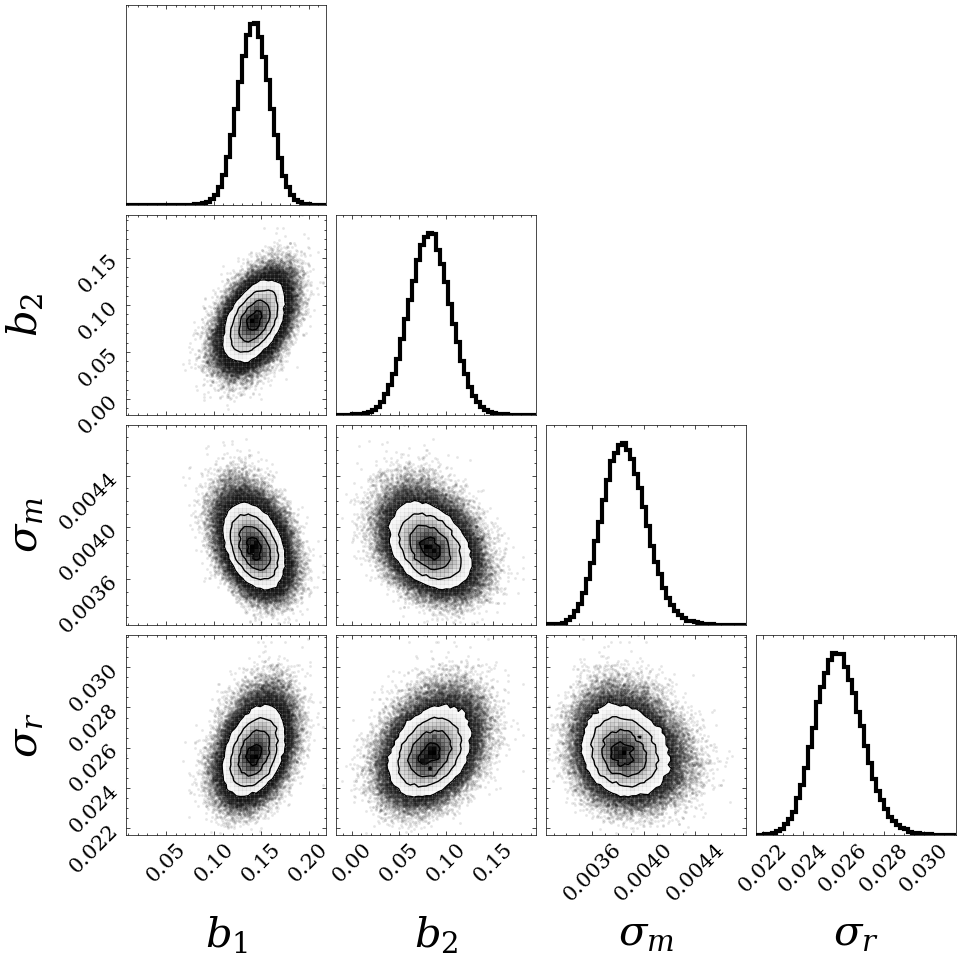

In [471]:
label = [f'$b_{i}$' for i in range(1, components_kept +1)]
label.append(f'$\sigma_m$')
label.append(f'$\sigma_r$')

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)
figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label, 
                       # truths=beta,truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)


plt.show()

In [472]:
sigma_mass = samples[:,-2] * mass_std
sigma_radius = samples[:,-1] * radius_std

In [473]:
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights = np.array(model_weights)

model_weights.shape

(100000, 10)

In [474]:
mass_std

472.96503409748556

In [475]:
filtered_model_predictions_mass_50 = mass_std * filtered_models_output_mass_50.iloc[:,3:-1].values

In [476]:
filtered_model_predictions_mass_50.shape

(18, 10)

In [477]:
lower_mass, median_mass, upper_mass = rndm_m_mass_calculator(model_weights, filtered_model_predictions_mass_50, sigma_mass)

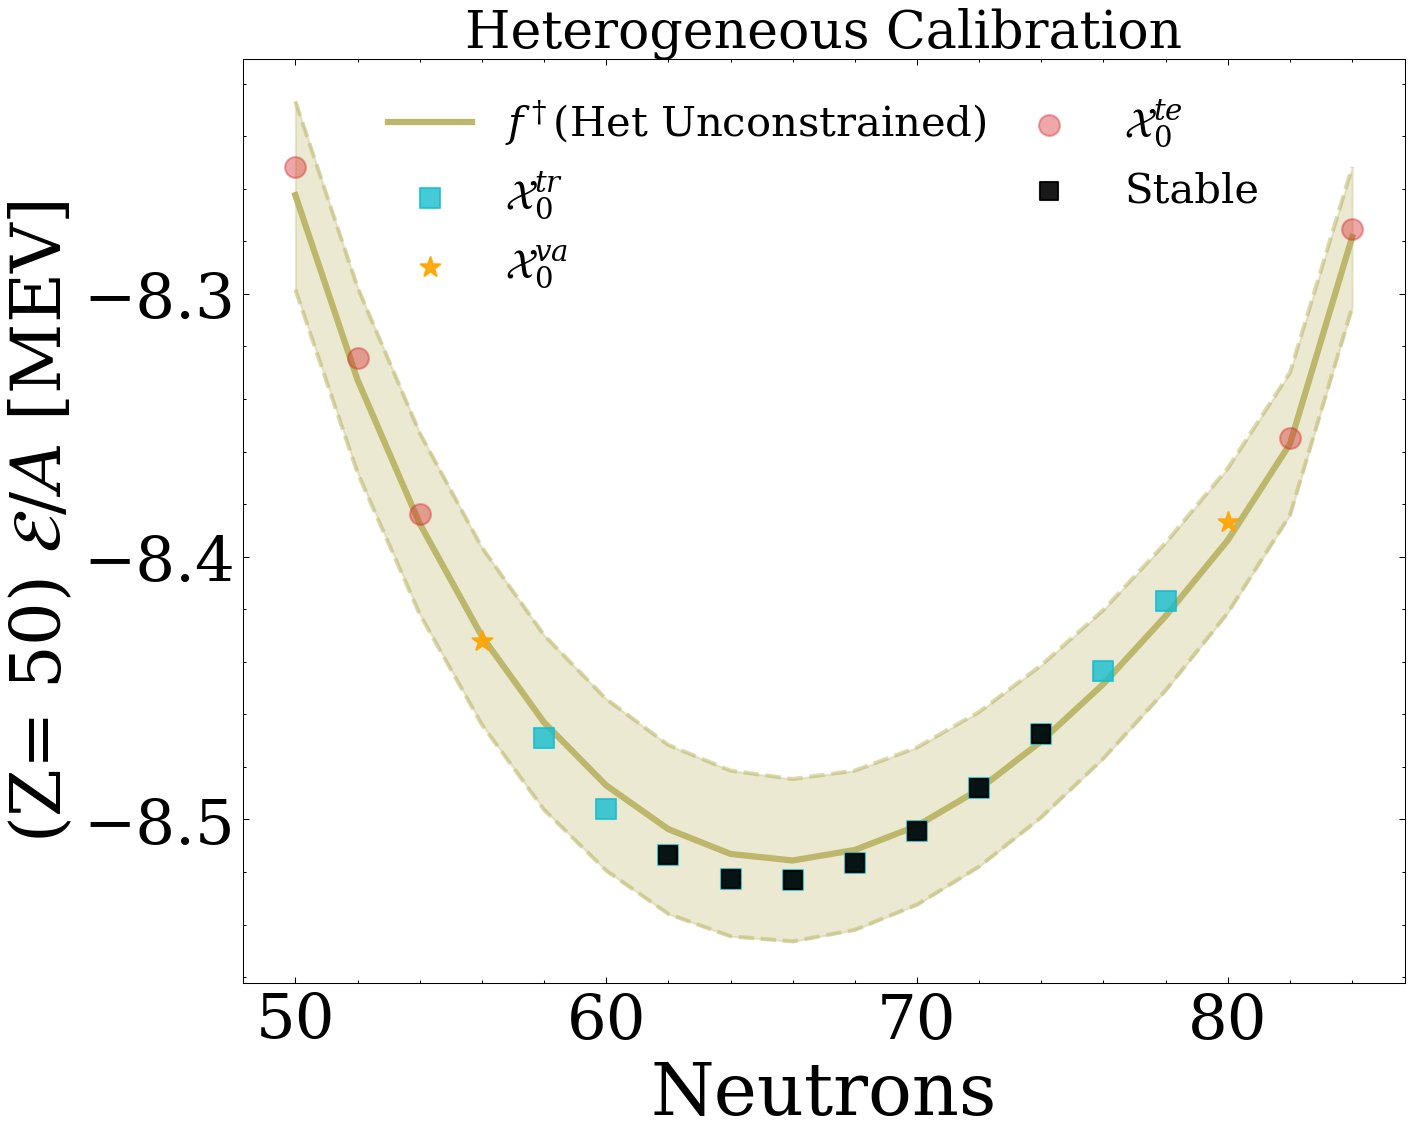

In [547]:
supermodel_predictions_mass_range = [lower_mass, median_mass, upper_mass]
title = 'Heterogeneous Calibration'
savefig_50_mass = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Unconstrained BE forecasts for Z = 50 - Heterogeneous Analysis - 2PCs.png'
plot_filtered_supermodel_mass(supermodel_predictions_mass_range, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Het Unconstrained', title, savefig_50_mass)

In [479]:
filtered_model_predictions_radius_20 = radius_std * filtered_models_output_radius_20.iloc[:,3:-1].values

In [480]:
lower_radius, median_radius, upper_radius = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_20, sigma_radius)

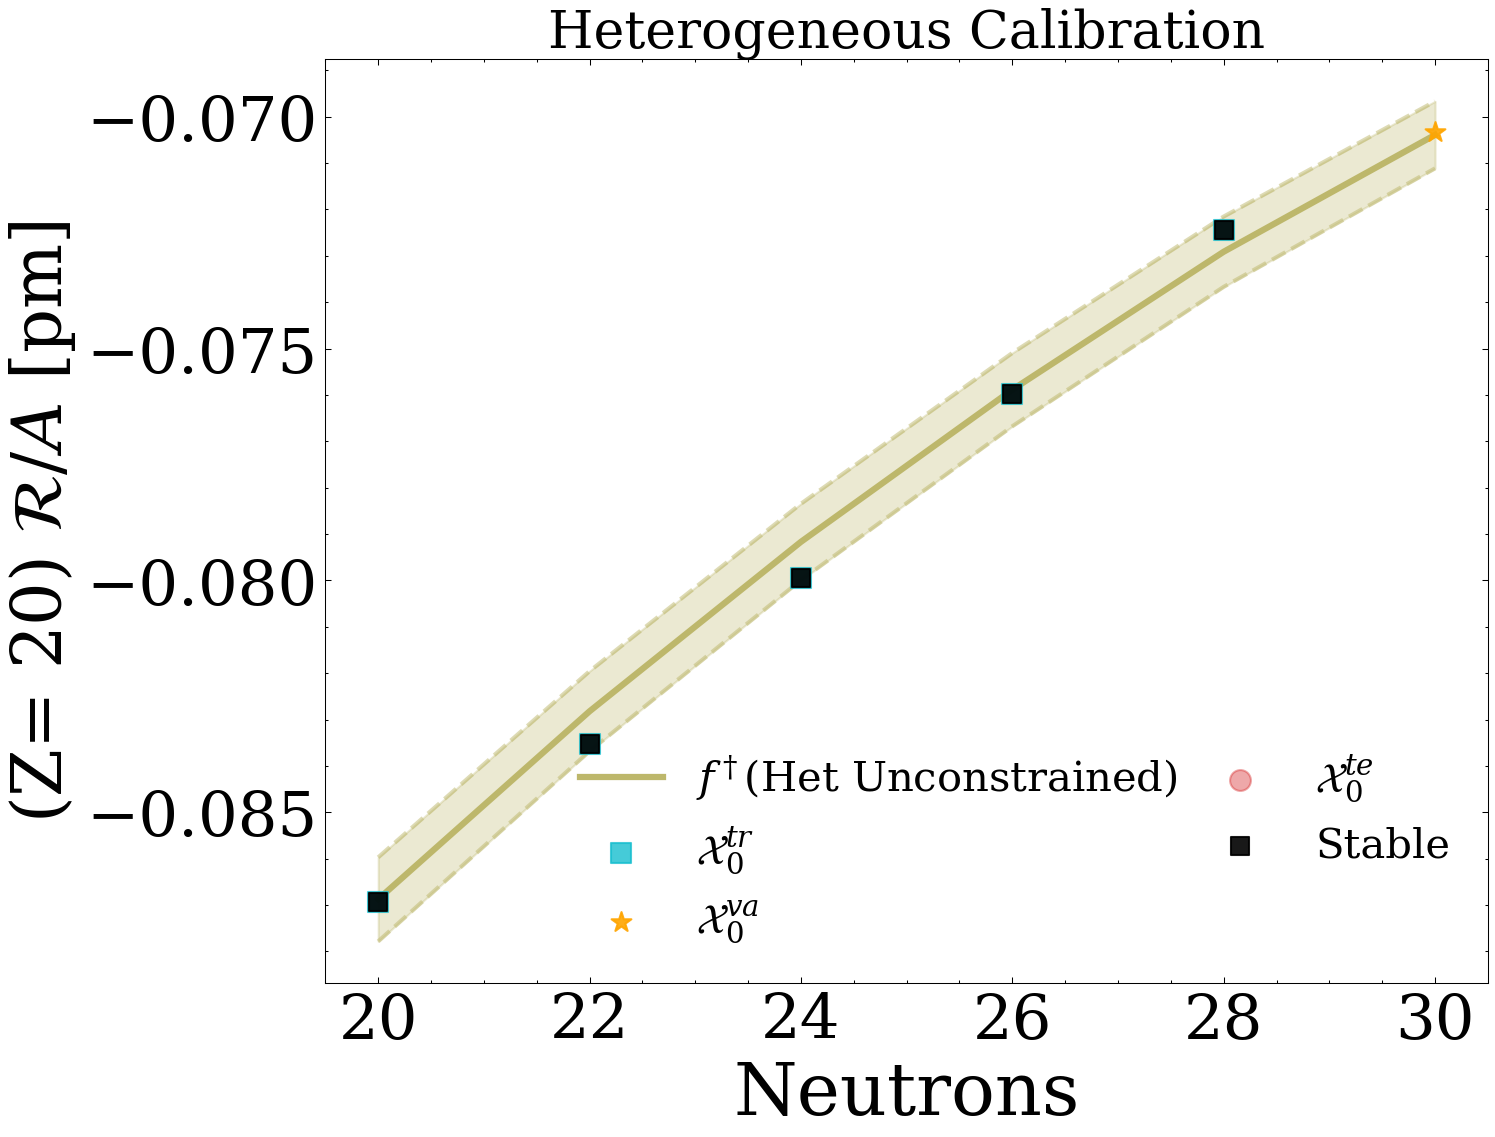

In [548]:
supermodel_predictions_radius_range = [lower_radius, median_radius, upper_radius]
# title = 'Heterogeneous Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Heterogeneous Analysis - 2PCs.png'
plot_filtered_supermodel_radius(supermodel_predictions_radius_range, filtered_models_output_radius_list_20, 20, 'pm', 'R', 'Het Unconstrained', title, savefig_20_radius)

### Simplex

In [482]:
nu0_chosen_mass=1
sigma20_chosen_mass= 0.5/mass_std

nu0_chosen_radius = 1
sigma20_chosen_radius = 0.05/radius_std
bias0=np.full(len(model_predictions_combined_train.T),1/len(model_predictions_combined_train.T))

In [428]:
def gibbs_sampler_simplex(y, X, iterations,prior_info_mass, prior_info_radius ,burn,stepsize):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    nu0_mass, sigma20_mass  =  prior_info_mass   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    nu0_radius, sigma20_radius = prior_info_radius
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)

    y_mass = y[:300]
    y_radius = y[300:]
    X_mass = X[:300,:]
    X_radius = X[300:,:]
    
    n = len(y_mass)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X.T),0)

    
    
    supermodel_mass_current=X_mass.dot(b_current)
    supermodel_radius_current=X_radius.dot(b_current)
    

    residuals_mass_current = y_mass - supermodel_mass_current 
    residuals_radius_current = y_radius - supermodel_radius_current 

    
  
    log_likelihood_mass_current= -np.sum(residuals_mass_current**2)
    log_likelihood_radius_current= -np.sum(residuals_radius_current**2)
    
    
    sigma2_mass = -log_likelihood_mass_current/ len(residuals_mass_current) 
    sigma2_radius = -log_likelihood_radius_current/ len(residuals_radius_current)
    
    samples_beta = []
    samples_sigma2_mass = []
    samples_sigma2_radius = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_mass_proposed=X_mass.dot(b_proposed)
    
            residuals_mass_proposed = y_mass - supermodel_mass_proposed 

            log_likelihood_mass_proposed= -np.sum(residuals_mass_proposed**2)

            supermodel_radius_proposed=X_radius.dot(b_proposed)
    
            residuals_radius_proposed = y_radius - supermodel_radius_proposed 

            log_likelihood_radius_proposed= -np.sum(residuals_radius_proposed**2)
            
#           Calculate the acceptancte probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_mass_proposed - log_likelihood_mass_current)/sigma2_mass  \
                                             + (+log_likelihood_radius_proposed - log_likelihood_radius_current)/sigma2_radius   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_mass_current=log_likelihood_mass_proposed
                log_likelihood_radius_current=log_likelihood_radius_proposed
                
        shape_post_mass = (nu0_mass + n)/2
        shape_post_radius = (nu0_radius + n)/2
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post_mass = (nu0_mass*sigma20_mass - log_likelihood_mass_current)/2.0
        scale_post_radius = (nu0_radius*sigma20_radius - log_likelihood_radius_current)/2.0
        
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post_mass, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post_radius, 1/scale_post_radius)
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            
            supermodel_mass_proposed=X_mass.dot(b_proposed)
    
            residuals_mass_proposed = y_mass - supermodel_mass_proposed 

            log_likelihood_mass_proposed= -np.sum(residuals_mass_proposed**2)

            supermodel_radius_proposed=X_radius.dot(b_proposed)
    
            residuals_radius_proposed = y_radius - supermodel_radius_proposed 

            log_likelihood_radius_proposed= -np.sum(residuals_radius_proposed**2)
            
#           Calculate the acceptancte probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_mass_proposed - log_likelihood_mass_current)/sigma2_mass  \
                                             + (+log_likelihood_radius_proposed - log_likelihood_radius_current)/sigma2_radius   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_mass_current=log_likelihood_mass_proposed
                log_likelihood_radius_current=log_likelihood_radius_proposed
                acceptance=acceptance+1
        samples_beta.append(b_current)
        
        shape_post_mass = (nu0_mass + n)/2.
        shape_post_radius = (nu0_radius + n)/2
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post_mass = (nu0_mass*sigma20_mass - log_likelihood_mass_current)/2.0
        scale_post_radius = (nu0_radius*sigma20_radius - log_likelihood_radius_current)/2.0
        
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post_mass, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post_radius, 1/scale_post_radius)

        samples_sigma2_mass.append(sigma2_mass)
        samples_sigma2_radius.append(sigma2_radius) 

    
    samples_beta = np.array(samples_beta)
    samples_sigma2_mass = np.array(samples_sigma2_mass).reshape(iterations,1)
    samples_sigma2_radius = np.array(samples_sigma2_radius).reshape(iterations,1)

    samples = np.hstack((samples_beta, np.sqrt(samples_sigma2_mass), np.sqrt(samples_sigma2_radius)))       
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return  samples

In [483]:
%%time
samples_simplex=gibbs_sampler_simplex(y, X, 500000,[nu0_chosen_mass, sigma20_chosen_mass],[nu0_chosen_radius, sigma20_chosen_radius],  burn=300000,stepsize=0.015)

percentage accepted: 26
CPU times: total: 1min 59s
Wall time: 2min


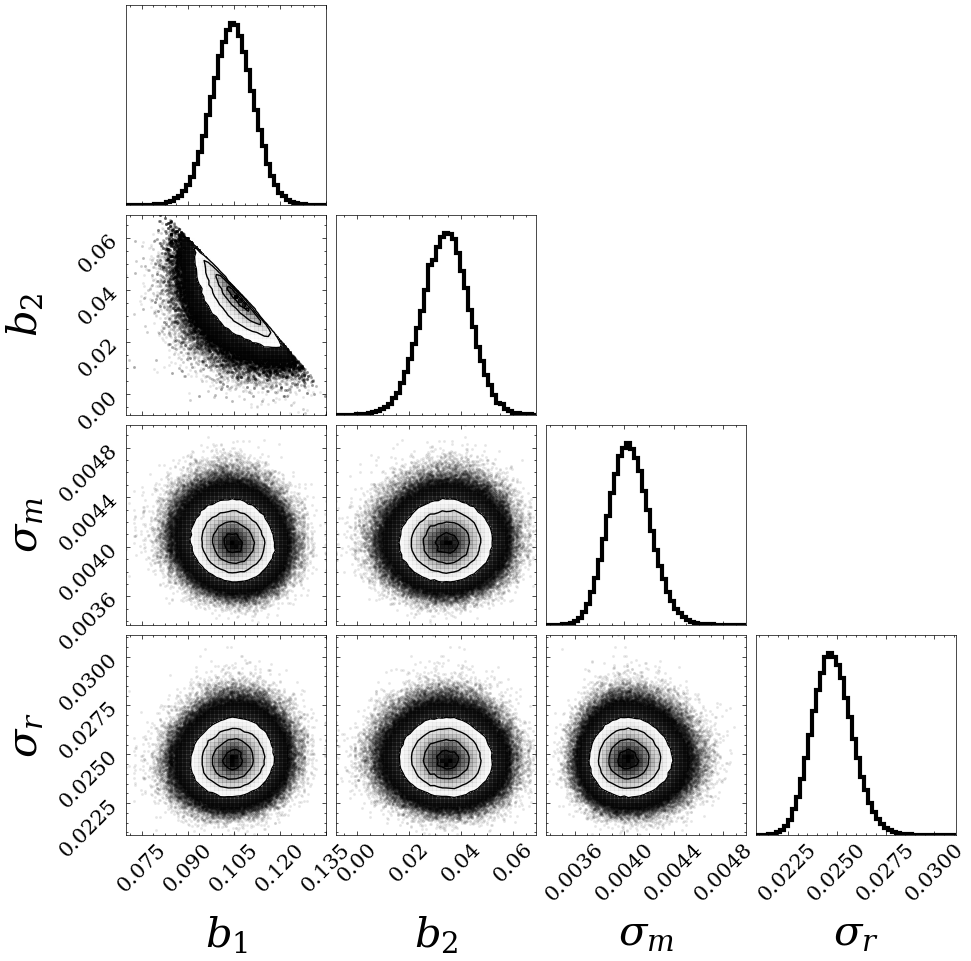

In [484]:
label = [f'$b_{i}$' for i in range(1, components_kept +1)]
label.append(f'$\sigma_m$')
label.append(f'$\sigma_r$')

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)
figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label, 
                       # truths=beta,truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)


plt.show()

In [485]:
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex = np.array(model_weights_simplex)

model_weights_simplex.shape

(500000, 10)

In [486]:
filtered_model_predictions_mass_50 = mass_std* filtered_models_output_mass_50.iloc[:,3:-1].values
filtered_model_predictions_radius_20 = radius_std* filtered_models_output_radius_20.iloc[:,3:-1].values

sigma_mass_simplex = samples_simplex[:,-2]*mass_std
sigma_radius_simplex = samples_simplex[:,-1]*radius_std

lower_mass_simplex, median_mass_simplex, upper_mass_simplex = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_50, sigma_mass_simplex)
lower_radius_simplex, median_radius_simplex, upper_radius_simplex = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_20, sigma_radius_simplex)

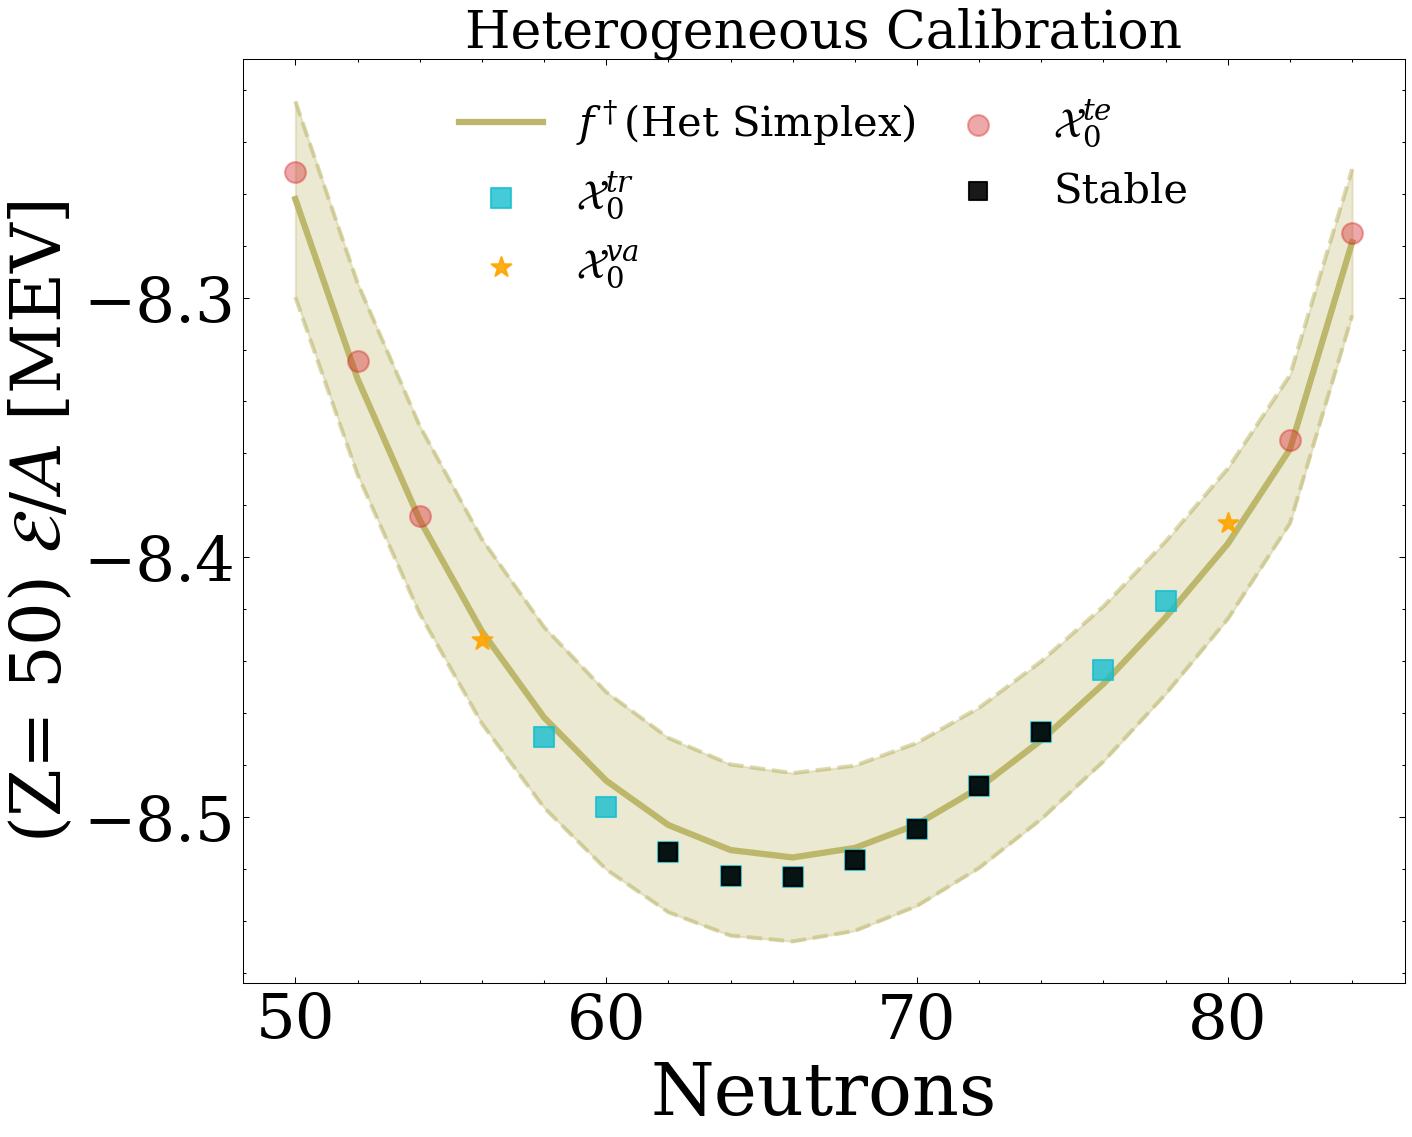

In [549]:
supermodel_predictions_mass_range_simplex = [lower_mass_simplex, median_mass_simplex, upper_mass_simplex]
# title = 'Heterogeneous Calibration'
# savefig_50_mass_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Simplex BE forecasts for Z = 50 - Heterogeneous Analysis - 2PCs.png'
plot_filtered_supermodel_mass(supermodel_predictions_mass_range_simplex, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Het Simplex',title, savefig_50_mass_simplex)

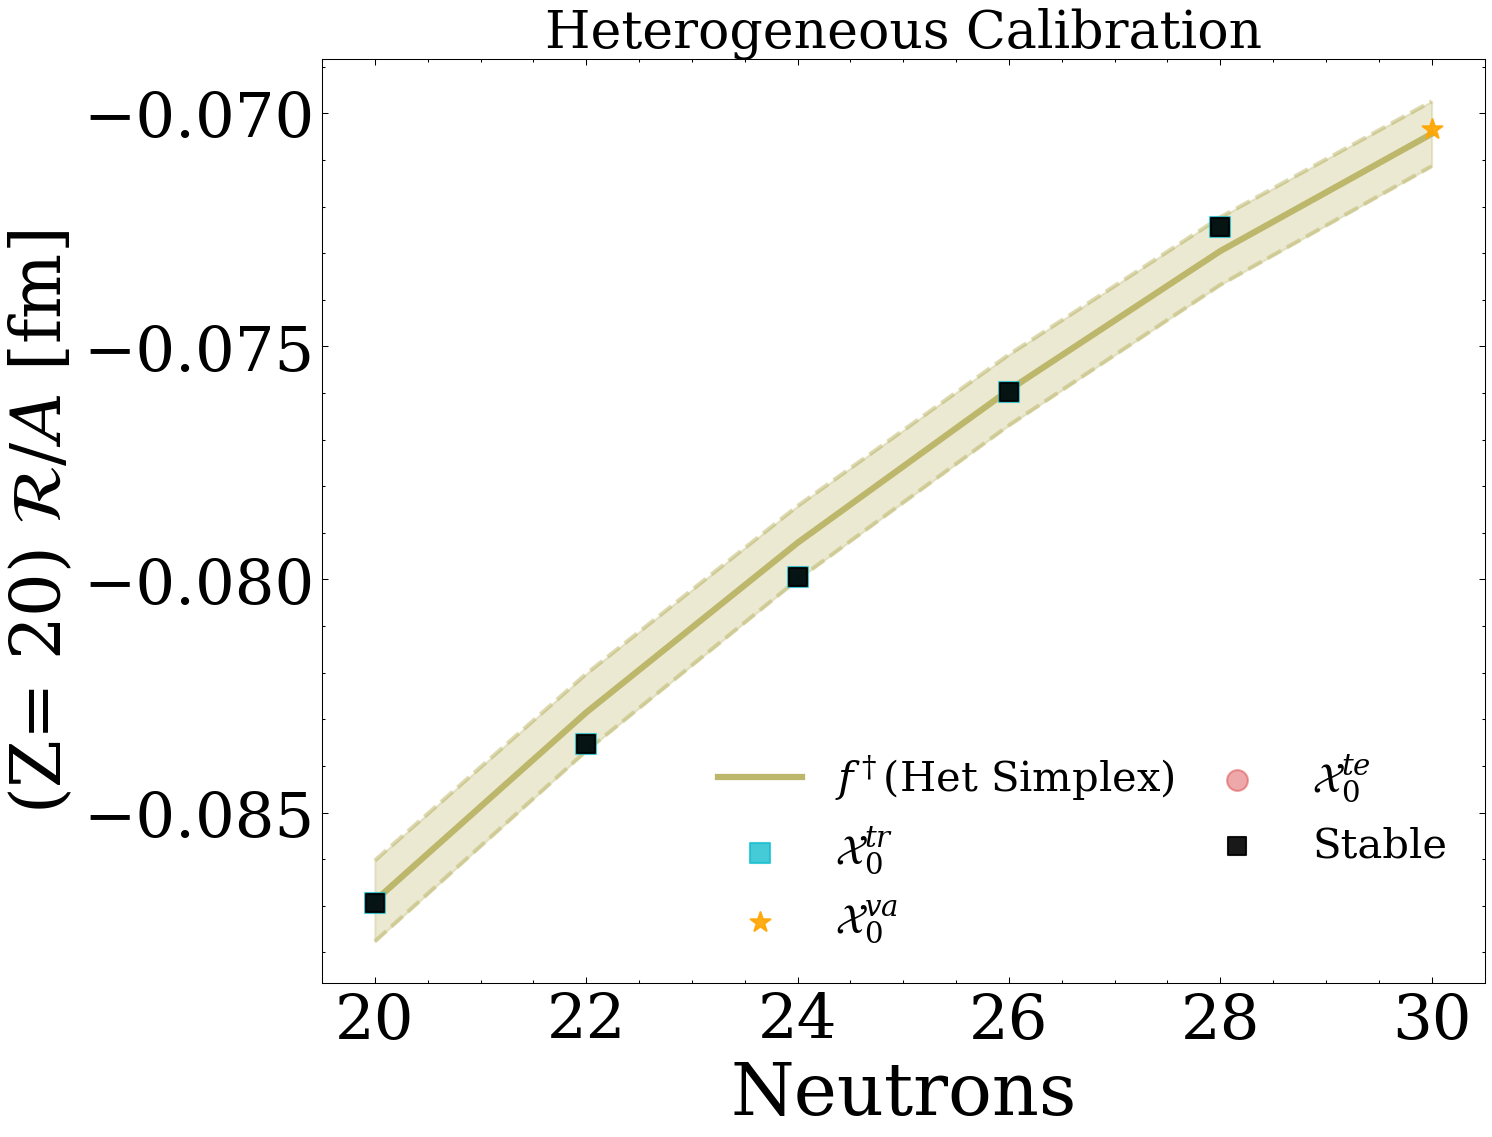

In [551]:
supermodel_predictions_radius_range_simplex = [lower_radius_simplex, median_radius_simplex, upper_radius_simplex]
# title = 'Heterogeneous Calibration'
# savefig_20_radius_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Simplex CR forecasts for Z = 20 - Heterogeneous Analysis - 2PCs.png'
plot_filtered_supermodel_radius(supermodel_predictions_radius_range_simplex, filtered_models_output_radius_list_20, 20, 'fm', 'R', 'Het Simplex', title, savefig_20_radius_simplex)

# Z = 60

In [723]:
# filtered_models_output_mass_list_60 = filtered_models_output(60, models_output_mass_list)
# filtered_models_output_radius_list_60 = filtered_models_output(60, models_output_radius_list)

# filtered_models_output_mass_60 = filtered_models_output_mass_list_60[0]
# filtered_models_output_radius_60 = filtered_models_output_radius_list_60[0]

# filtered_model_predictions_mass_60 = filtered_models_output_mass_60.iloc[:,3:-1].values
# filtered_model_predictions_radius_60 = filtered_models_output_radius_60.iloc[:,3:-1].values

In [724]:
# lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60 = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_60, samples_simplex)
# lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_60, samples_simplex)

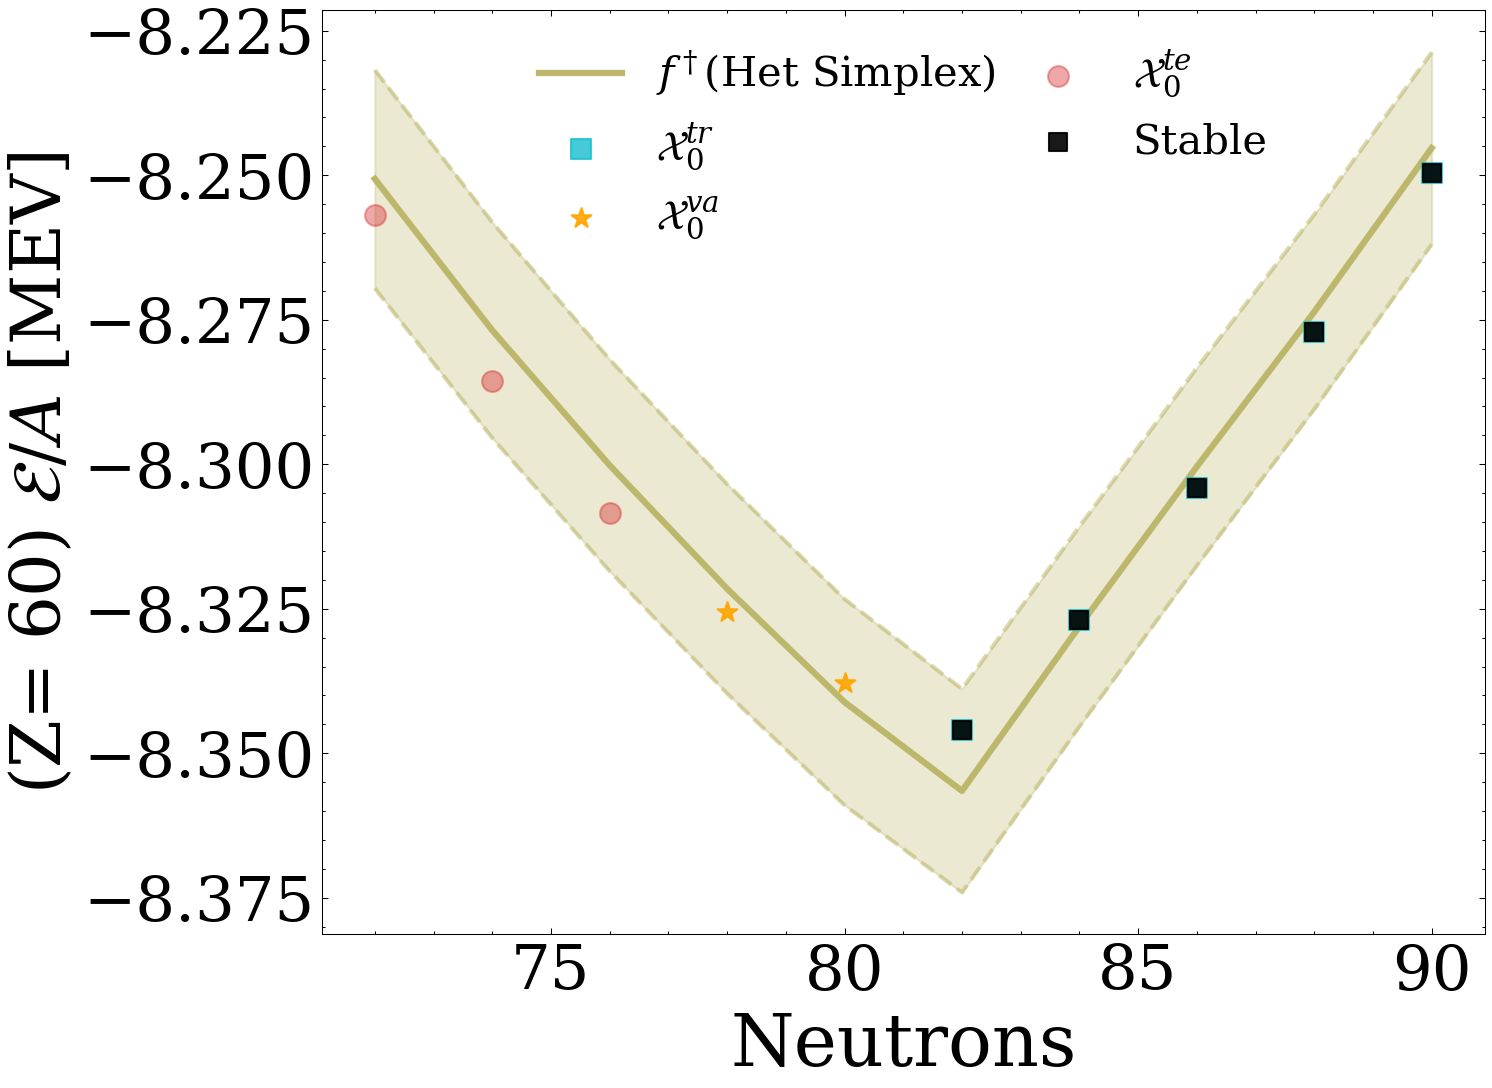

In [725]:
# supermodel_predictions_mass_range_simplex_60 = [lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60]
# savefig_60_mass_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Mass forecasts for Z = 60 in Heterogeneous Combined Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_60, filtered_models_output_mass_list_60, 60, 'MEV', 'E', 'Het Simplex', savefig_60_mass_simplex)

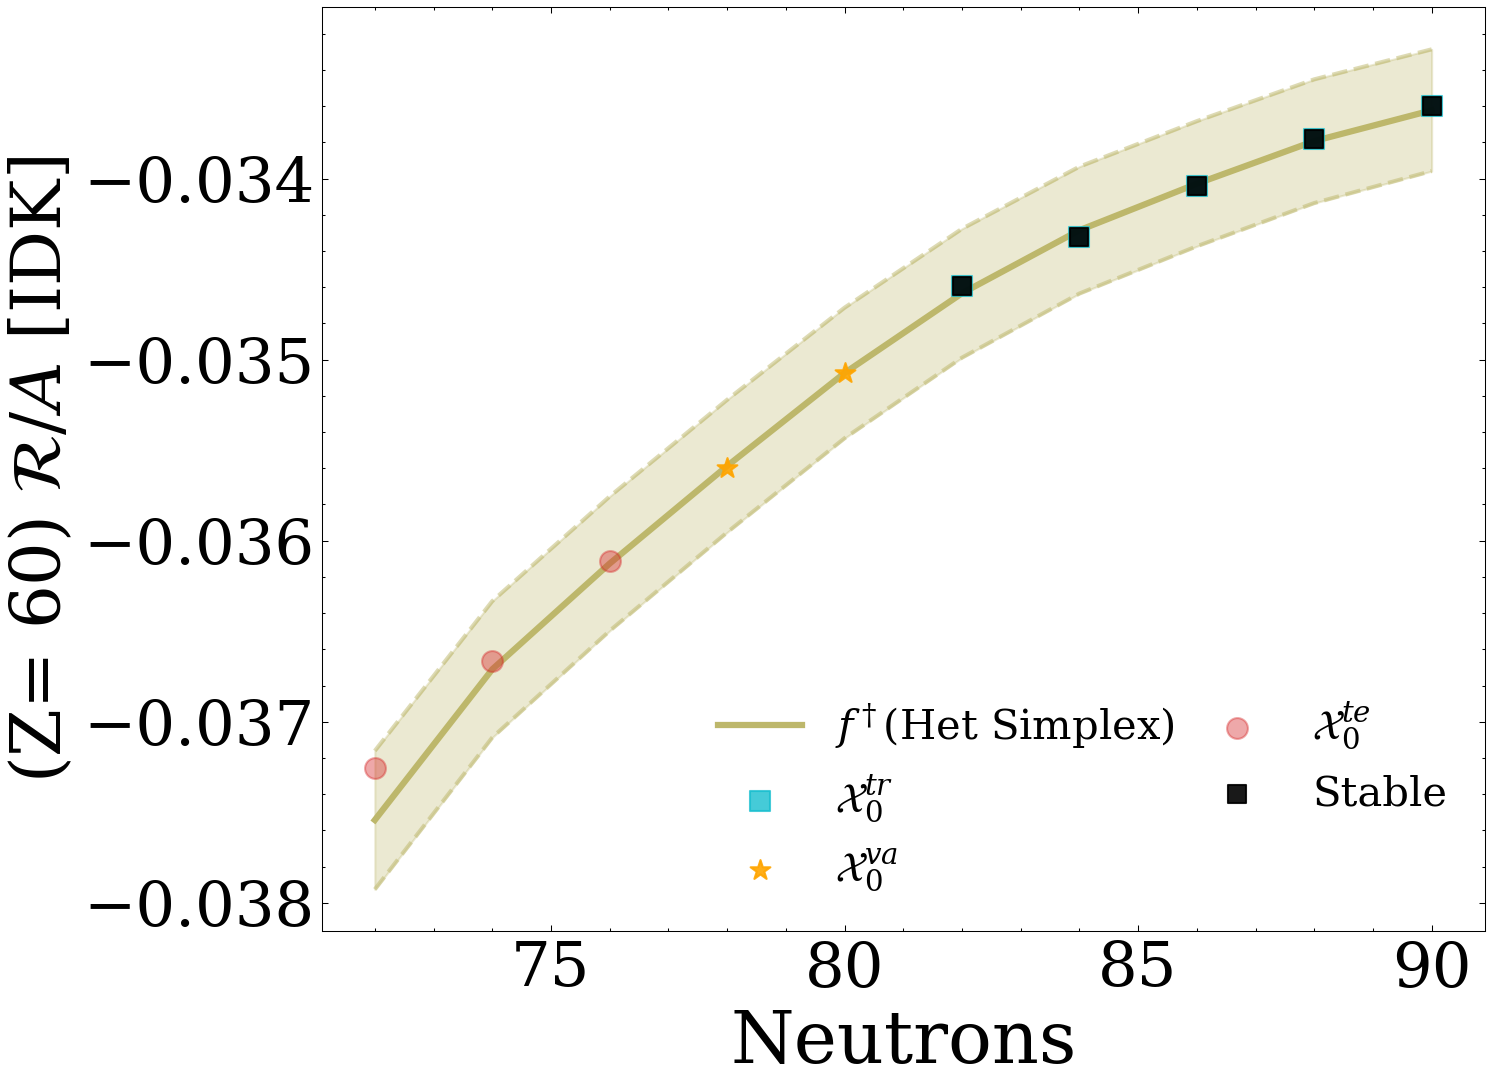

In [726]:
# supermodel_predictions_radius_range_simplex_60 = [lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60]
# savefig_60_radius_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Radius forecasts for Z = 60 in Heterogeneous Combined Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_60, filtered_models_output_radius_list_60, 60, 'IDK', 'R', 'Het Simplex', savefig_60_radius_simplex)

# Z = 80

In [727]:
# filtered_models_output_mass_list_80 = filtered_models_output(80, models_output_mass_list)
# filtered_models_output_radius_list_80 = filtered_models_output(80, models_output_radius_list)

# filtered_models_output_mass_80 = filtered_models_output_mass_list_80[0]
# filtered_models_output_radius_80 = filtered_models_output_radius_list_80[0]

# filtered_model_predictions_mass_80 = filtered_models_output_mass_80.iloc[:,3:-1].values
# filtered_model_predictions_radius_80 = filtered_models_output_radius_80.iloc[:,3:-1].values

In [728]:
# lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80 = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_80, samples_simplex)
# lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_80, samples_simplex)

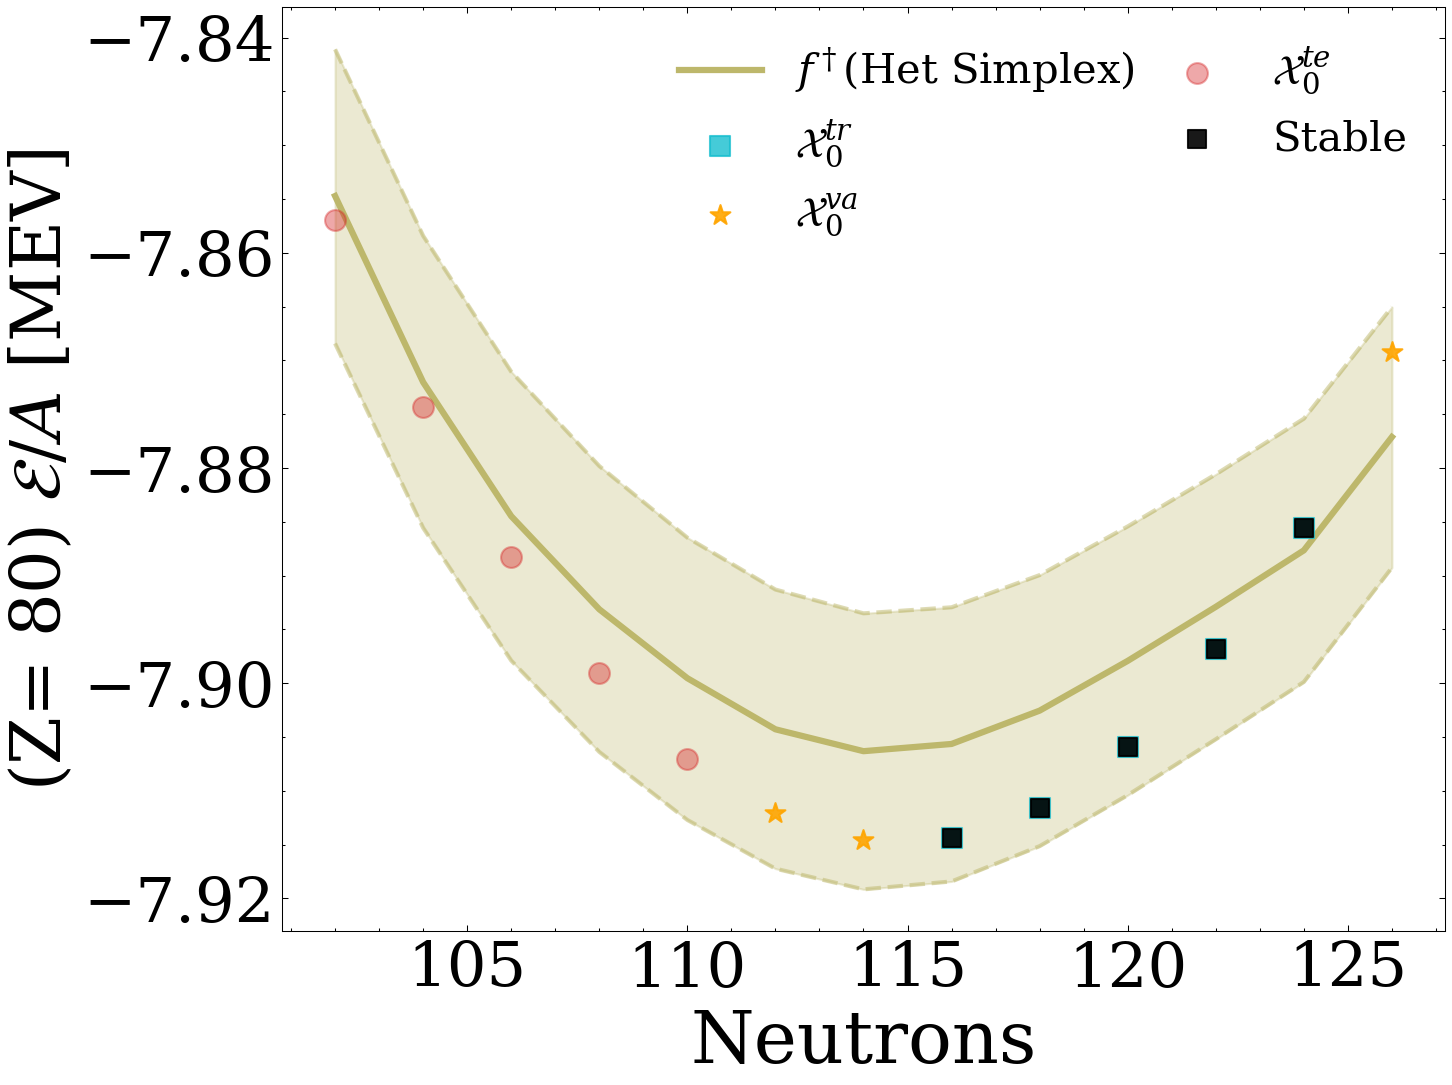

In [729]:
# supermodel_predictions_mass_range_simplex_80 = [lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80]
# savefig_80_mass_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Mass forecasts for Z = 80 in Heterogeneous Combined Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_80, filtered_models_output_mass_list_80, 80, 'MEV', 'E', 'Het Simplex', savefig_80_mass_simplex)

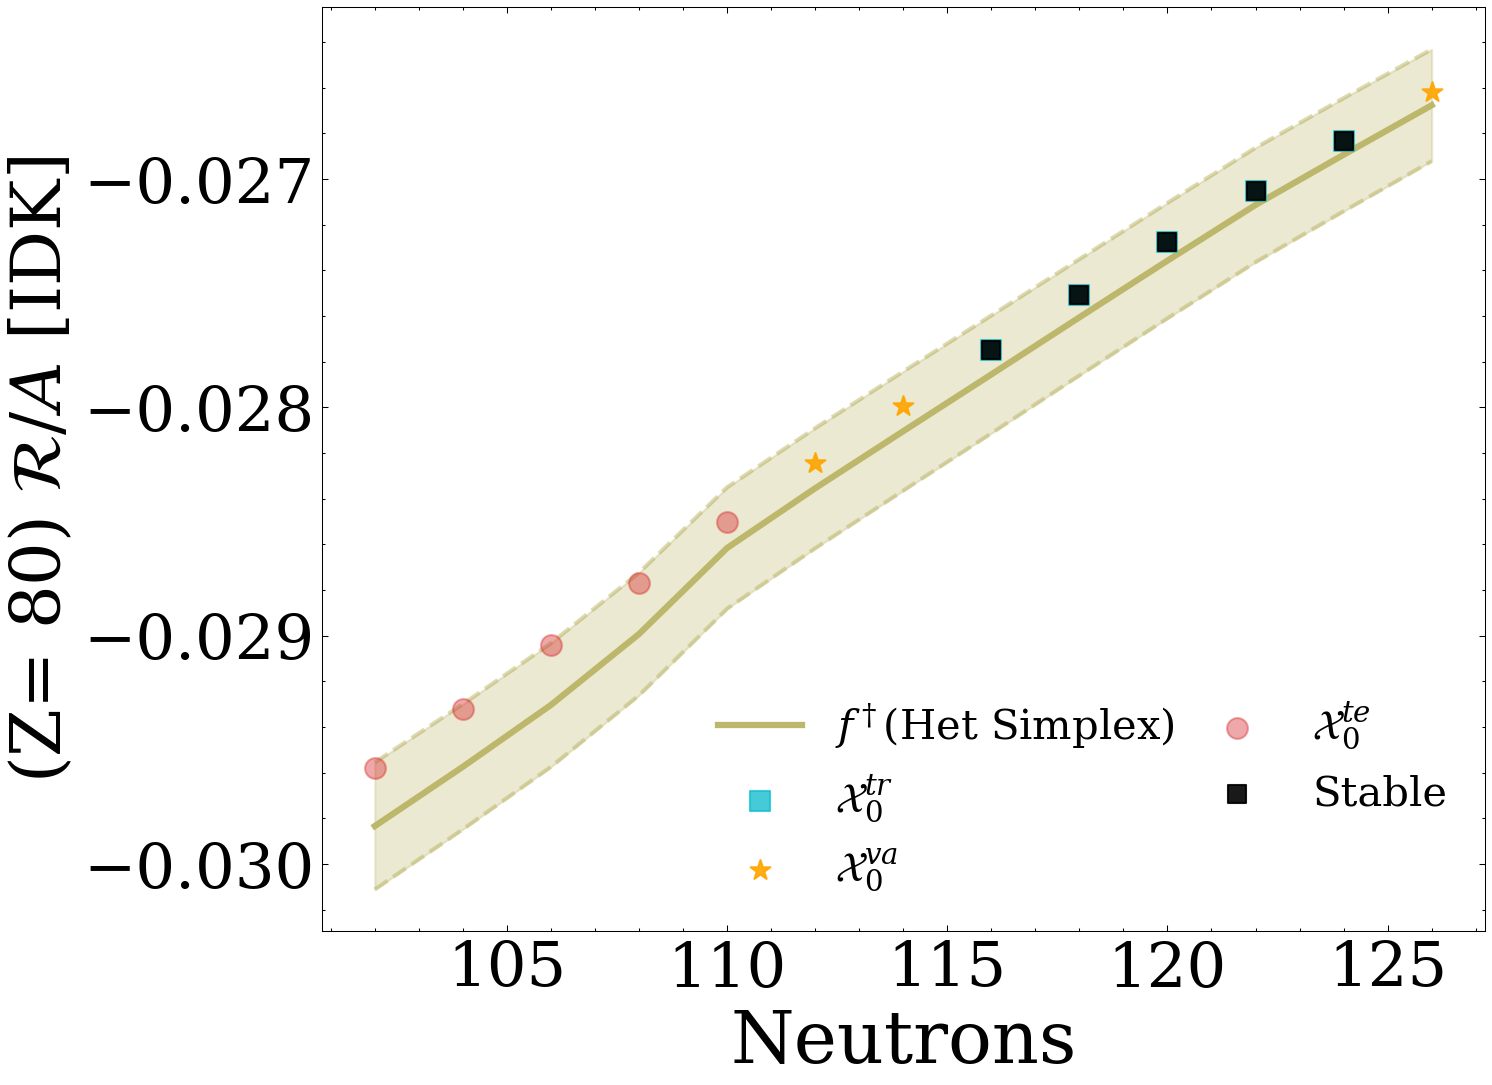

In [730]:
# supermodel_predictions_radius_range_simplex_80 = [lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80]
# savefig_80_radius_simplex = 'Plots/Heterogeneous with Experimental Data/Simplex Radius forecasts for Z = 80 in Heterogeneous Combined Analysis - 2PCs.png'
# plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_80, filtered_models_output_radius_list_80, 80, 'IDK', 'R', 'Het Simplex', savefig_80_radius_simplex)

### The next step is to compare the weights of the models when calibrating using different properties

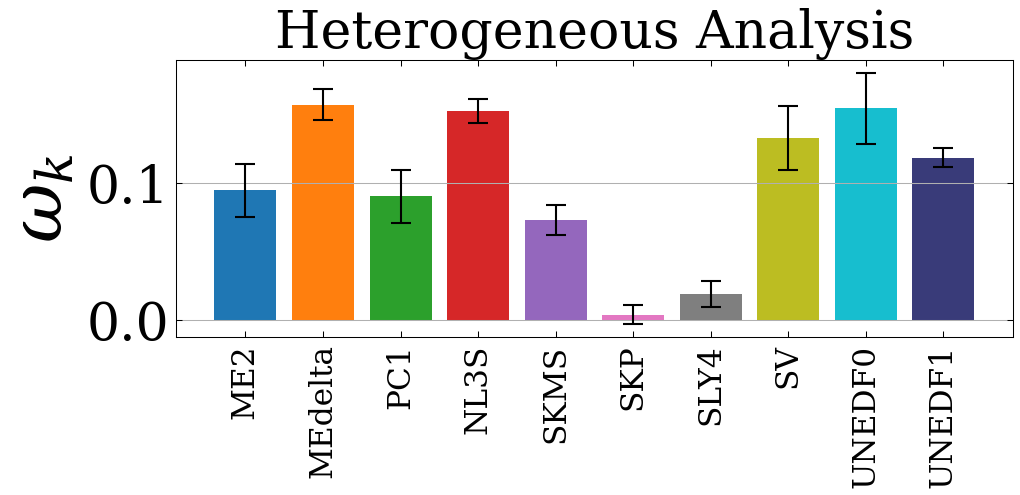

In [553]:
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
# labels=list(models_output.keys())
plt.figure(figsize=(7, 3.5),dpi=150)
# y_max=0.6


i=0
for model in key_list:
        
        # ax.plot(filtered_models_output["N"], filtered_models_output[key_list[model_index]], 
        #         label = n_Labels[class_index], color=colors[class_index],alpha = alpha_models,linewidth=5)
        # plt.bar(model , np.mean(samples_naive_space_sigma.T[i]), color=colors[i])
        plt.bar(model , 
                np.mean(model_weights_simplex, axis  = 0)[i],yerr=2*np.std(model_weights_simplex.T[i]),
                color=colors[i],capsize=5)
        i=i+1




# plt.xlabel('Models',fontsize=15)
# plt.title("c)",fontsize=25)
plt.minorticks_off()
plt.ylabel('$\omega_k$',fontsize=35)
# plt.ylim(0,0.45)
plt.xticks(fontsize=15,rotation='vertical')
plt.yticks(fontsize=25)
plt.grid(axis='y')
plt.title('Heterogeneous Analysis', fontsize = 25)
plt.tight_layout()
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Model weights/Simplex models weights - Heterogeneous Analysis - 2PCs.png')
plt.show()


## The next step is to compare the performance of the coverage graph in both radius and mass with respect to our mass and radius analysis

In [489]:
rndm_m_full_mass_train_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:33<00:00, 150.25it/s]


In [490]:
rndm_m_full_mass_train_simplex.shape

(5000, 300)

In [491]:
rndm_m_full_mass_validation_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:01<00:00, 2520.75it/s]


In [492]:
rndm_m_full_mass_test_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:26<00:00, 188.02it/s]


In [493]:
rndm_m_full_radius_train_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:09<00:00, 511.79it/s]


In [494]:
rndm_m_full_radius_validation_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:01<00:00, 2640.43it/s]


In [495]:
rndm_m_full_radius_test_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:03<00:00, 1250.77it/s]


In [496]:
coverage_mass_train_simplex = coverage_calculation(rndm_m_full_mass_train_simplex, models_output_mass_train)

In [497]:
coverage_mass_validation_simplex = coverage_calculation(rndm_m_full_mass_validation_simplex, models_output_mass_validation)

In [498]:
coverage_mass_test_simplex = coverage_calculation(rndm_m_full_mass_test_simplex, models_output_mass_test)

In [499]:
percentiles = np.arange(0,101,5)

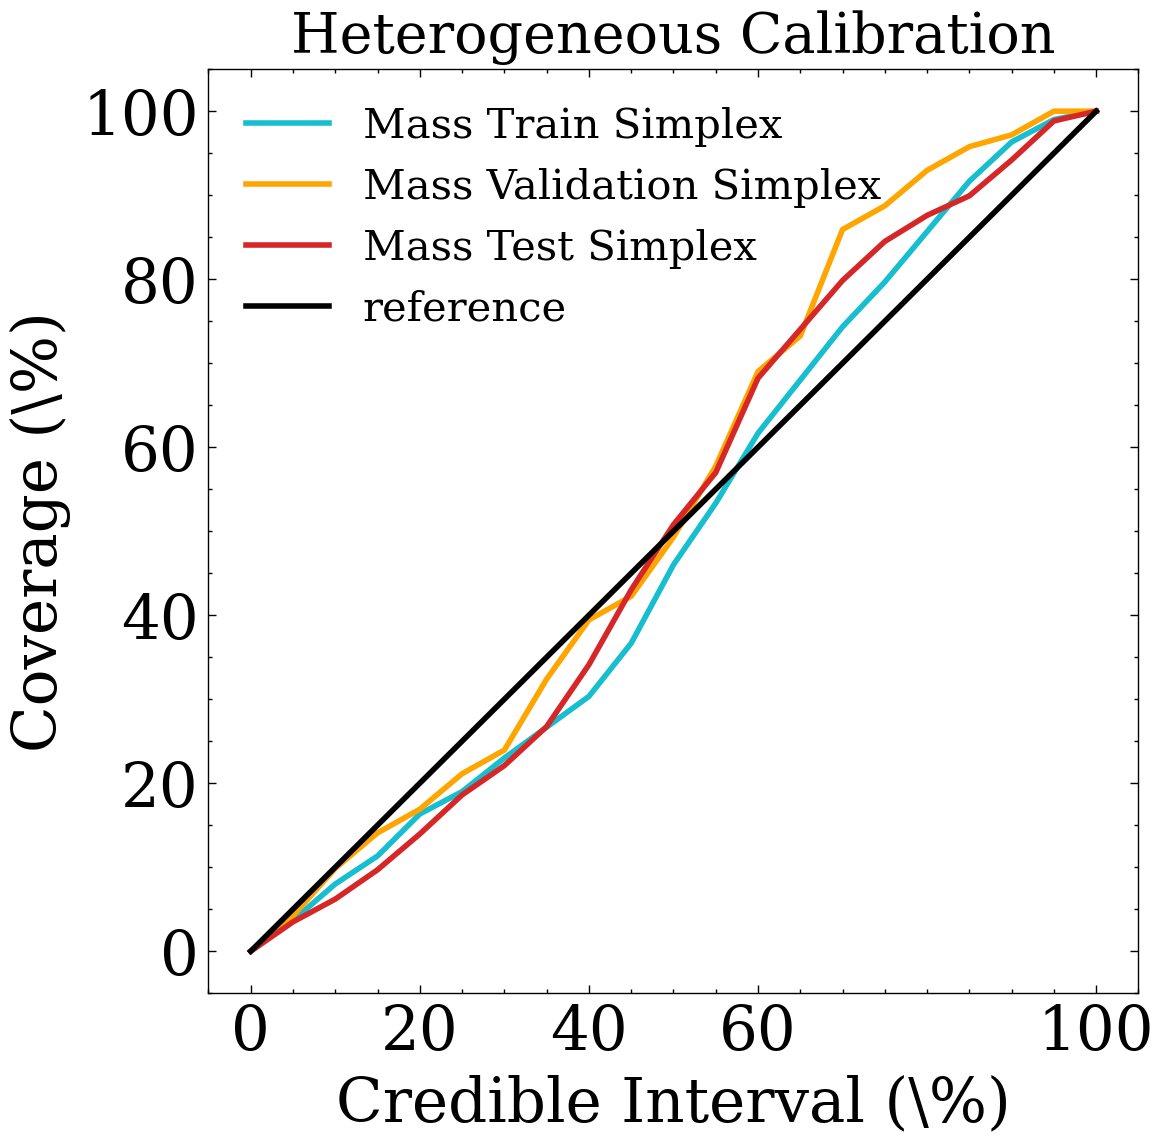

In [556]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_mass_train_simplex, label='Mass Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_mass_validation_simplex, label='Mass Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_mass_test_simplex, label='Mass Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Heterogeneous Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Mass ECP - Heterogeneous Analysis - 2PCs.png')
plt.show()

In [501]:
coverage_radius_train_simplex = coverage_calculation(rndm_m_full_radius_train_simplex, models_output_radius_train)

In [502]:
coverage_radius_validation_simplex = coverage_calculation(rndm_m_full_radius_validation_simplex, models_output_radius_validation)

In [503]:
coverage_radius_test_simplex = coverage_calculation(rndm_m_full_radius_test_simplex, models_output_radius_test)

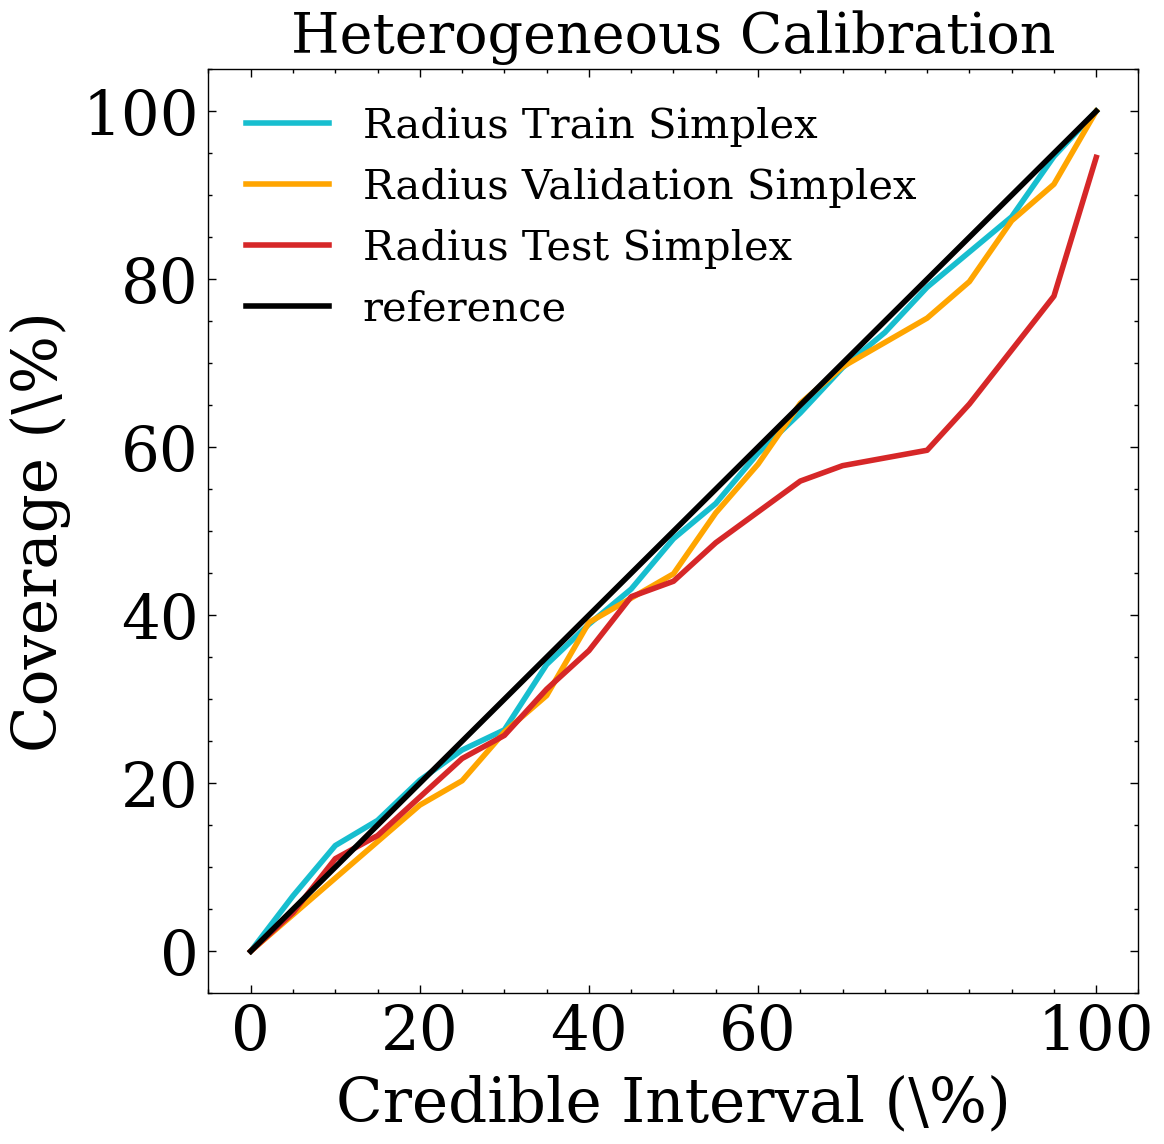

In [557]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_radius_train_simplex, label='Radius Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_radius_validation_simplex, label='Radius Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_radius_test_simplex, label='Radius Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Heterogeneous Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Radius ECP - Heterogeneous Analysis - 2PCs.png')
plt.show()

In [852]:
# def PC_RMSE_calculator_mass(components_kept, predictions_mean_list, models_output_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

#     predictions_mean = predictions_mean_list[0]
#     predictions_mean_train = predictions_mean_list[1]
#     predictions_mean_validation = predictions_mean_list[2]
#     predictions_mean_test = predictions_mean_list[3]

#     models_output = models_output_list[0]
#     models_output_train = models_output_list[1]
#     models_output_validation = models_output_list[2]
#     models_output_test = models_output_list[3]

#     model_predictions = model_predictions_list[0]
#     model_predictions_train = model_predictions_list[1]
#     model_predictions_validation = model_predictions_list[2]
#     model_predictions_test = model_predictions_list[3]

#     S_hat=np.array([S[i] for i in range(components_kept)])

#     # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
#     U_hat=np.array([U.T[i] for i in range(components_kept)])

#     # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
#     Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


#     if centering_data:
#         num_components=components_kept+1
#     else:
#         num_components=components_kept



#     #########################################
#     #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
#     models_PC_train = {}
#     if centering_data:
#         models_PC_train[str("PC_0")] = predictions_mean_train       
#     for i in range(components_kept):
#         models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
#     models_PC_train["N"] = models_output_train["N"]
#     models_PC_train["Z"] = models_output_train["Z"]
#     models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
#     # models_PC_training = pd.DataFrame(models_PC_train)
#     models_PC_train = pd.DataFrame(models_PC_train)
#     #########################################

#     #########################################
#     #Creating principal components that are for validation
#     models_PC_validation = {}
#     if centering_data:
#         models_PC_validation[str("PC_0")] = predictions_mean_validation
#     for i in range(components_kept):
#         models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
#     models_PC_validation["N"] = models_output_validation["N"]
#     models_PC_validation["Z"] = models_output_validation["Z"]
#     models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
#     models_PC_validation = pd.DataFrame(models_PC_validation)
#     #########################################

#     #########################################
#     #Creating principal components that are for testing
#     models_PC_testing = {}
#     if centering_data:
#         models_PC_testing[str("PC_0")] = predictions_mean_test
#     for i in range(components_kept):
#         # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
#         models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

#     models_PC_testing["N"] = models_output_test["N"]
#     models_PC_testing["Z"] = models_output_test["Z"]
#     models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
#     models_PC_testing = pd.DataFrame(models_PC_testing)
#     #########################################

#     #Creating principal components that are valid everywhere (testing + training + validation)
#     models_PC = {}
#     if centering_data:
#         models_PC[str("PC_0")] = predictions_mean
#     for i in range(components_kept):
#         models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
#     models_PC = pd.DataFrame(models_PC)
#     models_PC["N"] = Full_set.T[0]
#     models_PC["Z"] = Full_set.T[1]
#     models_PC["A"] = models_PC["N"] + models_PC["Z"]
#     #########################################

#     key_list_PCs=list(models_PC_testing.keys())


#     X=np.copy(U_hat)
#     if centering_data:
#         y=np.copy(models_output_train["truth"].tolist())-predictions_mean_train
#     else:
#         y=np.copy(models_output_train["truth"].tolist())
#     #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
#     X_train=[]
#     for i in range(num_components):
#         X_train.append(models_PC_train[key_list_PCs[i]].tolist())
#     X_train=np.array(X_train)
#     #Making the list of principal components across the validation part
#     X_validation=[]
#     for i in range(num_components):
#         X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
#     X_validation=np.array(X_validation)

#     #Making the list of principal components across the testing part
#     X_test=[]
#     for i in range(num_components):
#         X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
#     X_test=np.array(X_test)
#     #Making the list of principal components across the entire chart (training+validation+testing)
#     X_full=[]
#     for i in range(num_components):
#         X_full.append(models_PC[key_list_PCs[i]].tolist())
#     X_full=np.array(X_full)

#     X_train_centered = X_train[1:,:]

#     # 1) Find the least square solution for the training part
#     X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
#     beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
#     #1.5) Construct the super model across the entire range and the test range
#     if centering_data:
#         beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
#     else:
#         beta_full=np.copy(beta)

#     # supermodel=X.T.dot(beta_full)
#     supermodel=X_train[:300,:].T.dot(beta_full)
#     supermodel_train=np.copy(supermodel)
#     supermodel_validation=X_validation[:71,:].T.dot(beta_full)
#     supermodel_test=X_test[:258,:].T.dot(beta_full)
#     supermodel_full=X_full[:629,:].T.dot(beta_full)

    
#     super_model_residuals_train=supermodel_train-models_output_train['truth'][:300].tolist()
#     super_model_residuals_validation= supermodel_validation-models_output_validation['truth'][:71].tolist()
#     super_model_residuals_test = supermodel_test-models_output_test['truth'][:258].tolist()
#     super_model_residuals_full = supermodel_full-models_output['truth'][:629].tolist()

#     sigma_train=np.sqrt(np.sum(super_model_residuals_train**2) / len(super_model_residuals_train) )
#     sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
#     sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
#     sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


#     return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [853]:
# def PC_RMSE_calculator_radius(components_kept, predictions_mean_list, models_output_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

#     predictions_mean = predictions_mean_list[0]
#     predictions_mean_train = predictions_mean_list[1]
#     predictions_mean_validation = predictions_mean_list[2]
#     predictions_mean_test = predictions_mean_list[3]

#     models_output = models_output_list[0]
#     models_output_train = models_output_list[1]
#     models_output_validation = models_output_list[2]
#     models_output_test = models_output_list[3]

#     model_predictions = model_predictions_list[0]
#     model_predictions_train = model_predictions_list[1]
#     model_predictions_validation = model_predictions_list[2]
#     model_predictions_test = model_predictions_list[3]

#     S_hat=np.array([S[i] for i in range(components_kept)])

#     # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
#     U_hat=np.array([U.T[i] for i in range(components_kept)])

#     # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
#     Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


#     if centering_data:
#         num_components=components_kept+1
#     else:
#         num_components=components_kept



#     #########################################
#     #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
#     models_PC_train = {}
#     if centering_data:
#         models_PC_train[str("PC_0")] = predictions_mean_train       
#     for i in range(components_kept):
#         models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
#     models_PC_train["N"] = models_output_train["N"]
#     models_PC_train["Z"] = models_output_train["Z"]
#     models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
#     # models_PC_training = pd.DataFrame(models_PC_train)
#     models_PC_train = pd.DataFrame(models_PC_train)
#     #########################################

#     #########################################
#     #Creating principal components that are for validation
#     models_PC_validation = {}
#     if centering_data:
#         models_PC_validation[str("PC_0")] = predictions_mean_validation
#     for i in range(components_kept):
#         models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
#     models_PC_validation["N"] = models_output_validation["N"]
#     models_PC_validation["Z"] = models_output_validation["Z"]
#     models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
#     models_PC_validation = pd.DataFrame(models_PC_validation)
#     #########################################

#     #########################################
#     #Creating principal components that are for testing
#     models_PC_testing = {}
#     if centering_data:
#         models_PC_testing[str("PC_0")] = predictions_mean_test
#     for i in range(components_kept):
#         # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
#         models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

#     models_PC_testing["N"] = models_output_test["N"]
#     models_PC_testing["Z"] = models_output_test["Z"]
#     models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
#     models_PC_testing = pd.DataFrame(models_PC_testing)
#     #########################################

#     #Creating principal components that are valid everywhere (testing + training + validation)
#     models_PC = {}
#     if centering_data:
#         models_PC[str("PC_0")] = predictions_mean
#     for i in range(components_kept):
#         models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
#     models_PC = pd.DataFrame(models_PC)
#     models_PC["N"] = Full_set.T[0]
#     models_PC["Z"] = Full_set.T[1]
#     models_PC["A"] = models_PC["N"] + models_PC["Z"]
#     #########################################

#     key_list_PCs=list(models_PC_testing.keys())


#     X=np.copy(U_hat)
#     if centering_data:
#         y=np.copy(models_output_train["truth"].tolist())-predictions_mean_train
#     else:
#         y=np.copy(models_output_train["truth"].tolist())
#     #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
#     X_train=[]
#     for i in range(num_components):
#         X_train.append(models_PC_train[key_list_PCs[i]].tolist())
#     X_train=np.array(X_train)
#     #Making the list of principal components across the validation part
#     X_validation=[]
#     for i in range(num_components):
#         X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
#     X_validation=np.array(X_validation)

#     #Making the list of principal components across the testing part
#     X_test=[]
#     for i in range(num_components):
#         X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
#     X_test=np.array(X_test)
#     #Making the list of principal components across the entire chart (training+validation+testing)
#     X_full=[]
#     for i in range(num_components):
#         X_full.append(models_PC[key_list_PCs[i]].tolist())
#     X_full=np.array(X_full)

#     X_train_centered = X_train[1:,:]

#     # 1) Find the least square solution for the training part
#     X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
#     beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
#     #1.5) Construct the super model across the entire range and the test range
#     if centering_data:
#         beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
#     else:
#         beta_full=np.copy(beta)

#     # supermodel=X.T.dot(beta_full)
#     supermodel=X_train[300:,:].T.dot(beta_full)
#     supermodel_train=np.copy(supermodel)
#     supermodel_validation=X_validation[71:,:].T.dot(beta_full)
#     supermodel_test=X_test[258:,:].T.dot(beta_full)
#     supermodel_full=X_full[629:,:].T.dot(beta_full)

    
#     super_model_residuals_train=supermodel_train-models_output_train['truth'][300:].tolist()
#     super_model_residuals_validation= supermodel_validation-models_output_validation['truth'][71:].tolist()
#     super_model_residuals_test = supermodel_test-models_output_test['truth'][258:].tolist()
#     super_model_residuals_full = supermodel_full-models_output['truth'][629:].tolist()

#     sigma_train=np.sqrt(np.sum(super_model_residuals_train**2) / len(super_model_residuals_train) )
#     sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
#     sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
#     sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


#     return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [854]:
# predictions_mean_combined_list = [predictions_mean_combined, predictions_mean_combined_train, predictions_mean_combined_validation, predictions_mean_combined_test]
# models_output_combined_list = models_output_combined_list
# model_predictions_combined_list = [model_predictions_combined, model_predictions_combined_train, model_predictions_combined_validation, model_predictions_combined_test]

NameError: name 'models_output_combined_list' is not defined

In [638]:
# centering_data = True

In [639]:
# centering_data = True
# if centering_data:
#     s_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
#     s_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
#     s_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
#     s_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
# else:
#     s_test=[]
#     s_train=[]
#     s_validation=[]
#     s_all=[]

# if centering_data:
#     for i in range(1,len(S)):
#         res=PC_RMSE_calculator(i, predictions_mean_mass_list, models_output_mass_list, model_predictions_mass_list)
#         s_train.append(res[0])
#         s_validation.append(res[1])
#         s_test.append(res[2])
        
#         s_all.append(res[3])
# else:
#     for i in range(1,len(S)+1):
#         res=PC_RMSE_calculator(i)
#         s_train.append(res[0])
#         s_validation.append(res[1])
#         s_test.append(res[2])
        
#         s_all.append(res[3])

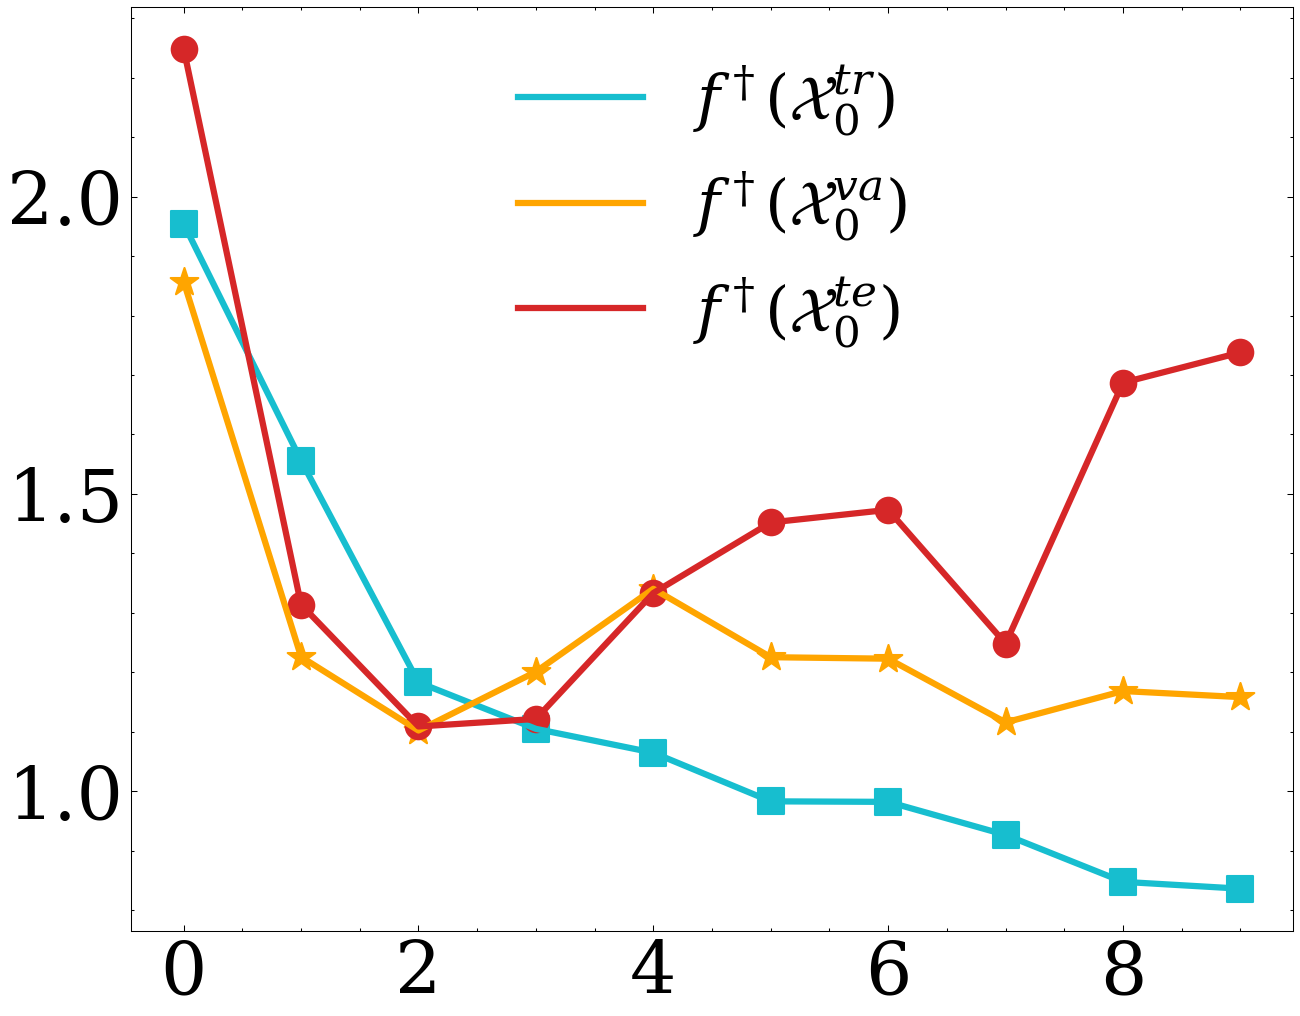

In [641]:
# plt.rc("xtick", labelsize=35)
# plt.rc("ytick", labelsize=35)

# fig, ax = plt.subplots(figsize=(10,8),dpi=150)
# fig.patch.set_facecolor('white')




# size_points=150


# ax.scatter(np.arange(0,len(s_train)), s_train,color=color_train,s=size_points,marker=marker_train)
# ax.plot(np.arange(0,len(s_train)), s_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

# ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_test)), s_test,color=color_test,s=size_points,marker=marker_test)
# ax.plot(np.arange(0,len(s_test)), s_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# # ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# # ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# # ax.set_yticks([0.2,0.5,1,2])


# # ax.set_yscale('log')
# # ax.set_xlabel(r'PC kept (p)',fontsize=40)
# # ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# # ax.set_xticks([0,5,10,15])

# # plt.ylim(2.5*10**(-1),2.3)

# # plt.legend(fontsize=20,loc=(0.1,0.6))
# # plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
# plt.legend(fontsize=30)
# plt.show()

## The next step is to see how the RMSE change when we add some importance of one of the 2 analysis

The basic idea is to add some weights to the likelihood function:
$$ \Large e^{-1/2\chi_1^2 p} \,\, e^{-1/2 \chi_2^2 (1-p)} $$
We are going to sample our parameters still from the Gibbs function but only for the unconstrained case

In [452]:
def weighted_gibbs_sampler(y, X, iterations, prior_info_mass, prior_info_radius, p):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0_mass, sigma20_mass  =  prior_info_mass
    nu0_radius, sigma20_radius = prior_info_radius
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)

    y_mass = y[:300]
    y_radius = y[300:]
    X_mass = X[:300,:]
    X_radius = X[300:,:]
    
    X_T_X_mass=X_mass.T.dot(X_mass)
    X_T_X_mass_inv = np.linalg.inv(X_T_X_mass)

    X_T_X_radius=X_radius.T.dot(X_radius)
    X_T_X_radius_inv = np.linalg.inv(X_T_X_radius)
    
    n = len(y_mass)
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2_mass = np.sum(residuals**2) / len(residuals) 
    sigma2_radius = np.sum(residuals**2) / len(residuals) 
    # cov_matrix = sigma2 * X_T_X_inv

    samples_beta = []
    samples_sigma2_mass = []
    samples_sigma2_radius = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X_mass*p/sigma2_mass + X_T_X_radius*(1-p)/sigma2_radius
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(   b_mean_cov_inv.dot(b_mean_prior)+ p*X_mass.T.dot(y_mass)/sigma2_mass + (1-p)*X_radius.T.dot(y_radius)/sigma2_radius  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel_mass=X_mass.dot(b_current)
        
        residuals_mass = y_mass - supermodel_mass

        supermodel_radius=X_radius.dot(b_current)
        
        residuals_radius = y_radius - supermodel_radius
        
        
        shape_post_mass = (nu0_mass + n)/2.
        shape_post_radius = (nu0_radius + n)/2
        
        scale_post_mass = (nu0_mass*sigma20_mass + np.sum(residuals_mass**2))/2.0
        scale_post_radius = (nu0_radius*sigma20_radius + np.sum(residuals_radius**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post_mass, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post_radius, 1/scale_post_radius)
        
        samples_beta.append(b_current)
        samples_sigma2_mass.append(sigma2_mass)
        samples_sigma2_radius.append(sigma2_radius)

    
    samples_beta = np.array(samples_beta)
    samples_sigma2_mass = np.array(samples_sigma2_mass).reshape(iterations,1)
    samples_sigma2_radius = np.array(samples_sigma2_radius).reshape(iterations,1)

    samples = np.hstack((samples_beta, np.sqrt(samples_sigma2_mass), np.sqrt(samples_sigma2_radius)))
    
    return samples

In [505]:
def weighted_RMSE_mass(p):
    samples = weighted_gibbs_sampler(y,X, 100000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_mass_chosen, sigma20_mass_chosen], [nu0_radius_chosen, sigma20_radius_chosen],p)
    mean_samples = np.mean(samples, axis = 0)

    # We should use the mean samples that we have to calculate both the radius and mass RMSE
    model_weights = np.dot(mean_samples[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])) # This translate from the PCs param to models' params
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_mass_train.T)
    supermodel_validation = model_weights.dot(model_predictions_mass_validation.T)
    supermodel_test = model_weights.dot(model_predictions_mass_test.T)
    supermodel_full = model_weights.dot(model_predictions_mass.T)
    
    supermodel_residuals_train=supermodel_train-models_output_mass_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_mass_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_mass_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_mass['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [506]:
def weighted_RMSE_radius(p):
    samples = weighted_gibbs_sampler(y,X, 100000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_mass_chosen, sigma20_mass_chosen],[nu0_radius_chosen, sigma20_radius_chosen],p)
    mean_samples = np.mean(samples, axis = 0)

    # We should use the mean samples that we have to calculate both the radius and mass RMSE
    model_weights = np.dot(mean_samples[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])) # This translate from the PCs param to models' params
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_radius_train.T)
    supermodel_validation = model_weights.dot(model_predictions_radius_validation.T)
    supermodel_test = model_weights.dot(model_predictions_radius_test.T)
    supermodel_full = model_weights.dot(model_predictions_radius.T)
    
    supermodel_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [507]:
importance = np.linspace(0,1,11)

In [508]:
%%time
weighted_RMSE_mass_list = []
for i in range(len(importance)):
    weighted_RMSE_mass_list.append(weighted_RMSE_mass(importance[i]))

CPU times: total: 3min 20s
Wall time: 3min 7s


In [509]:
%%time
weighted_RMSE_radius_list = []
for i in range(len(importance)):
    weighted_RMSE_radius_list.append(weighted_RMSE_radius(importance[i]))

CPU times: total: 3min 22s
Wall time: 3min 8s


In [510]:
weighted_RMSE_mass_matrix = np.copy(weighted_RMSE_mass_list)
weighted_RMSE_radius_matrix = np.copy(weighted_RMSE_radius_list)
weighted_RMSE_mass_matrix.shape

(11, 4)

In [511]:
p = ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1']

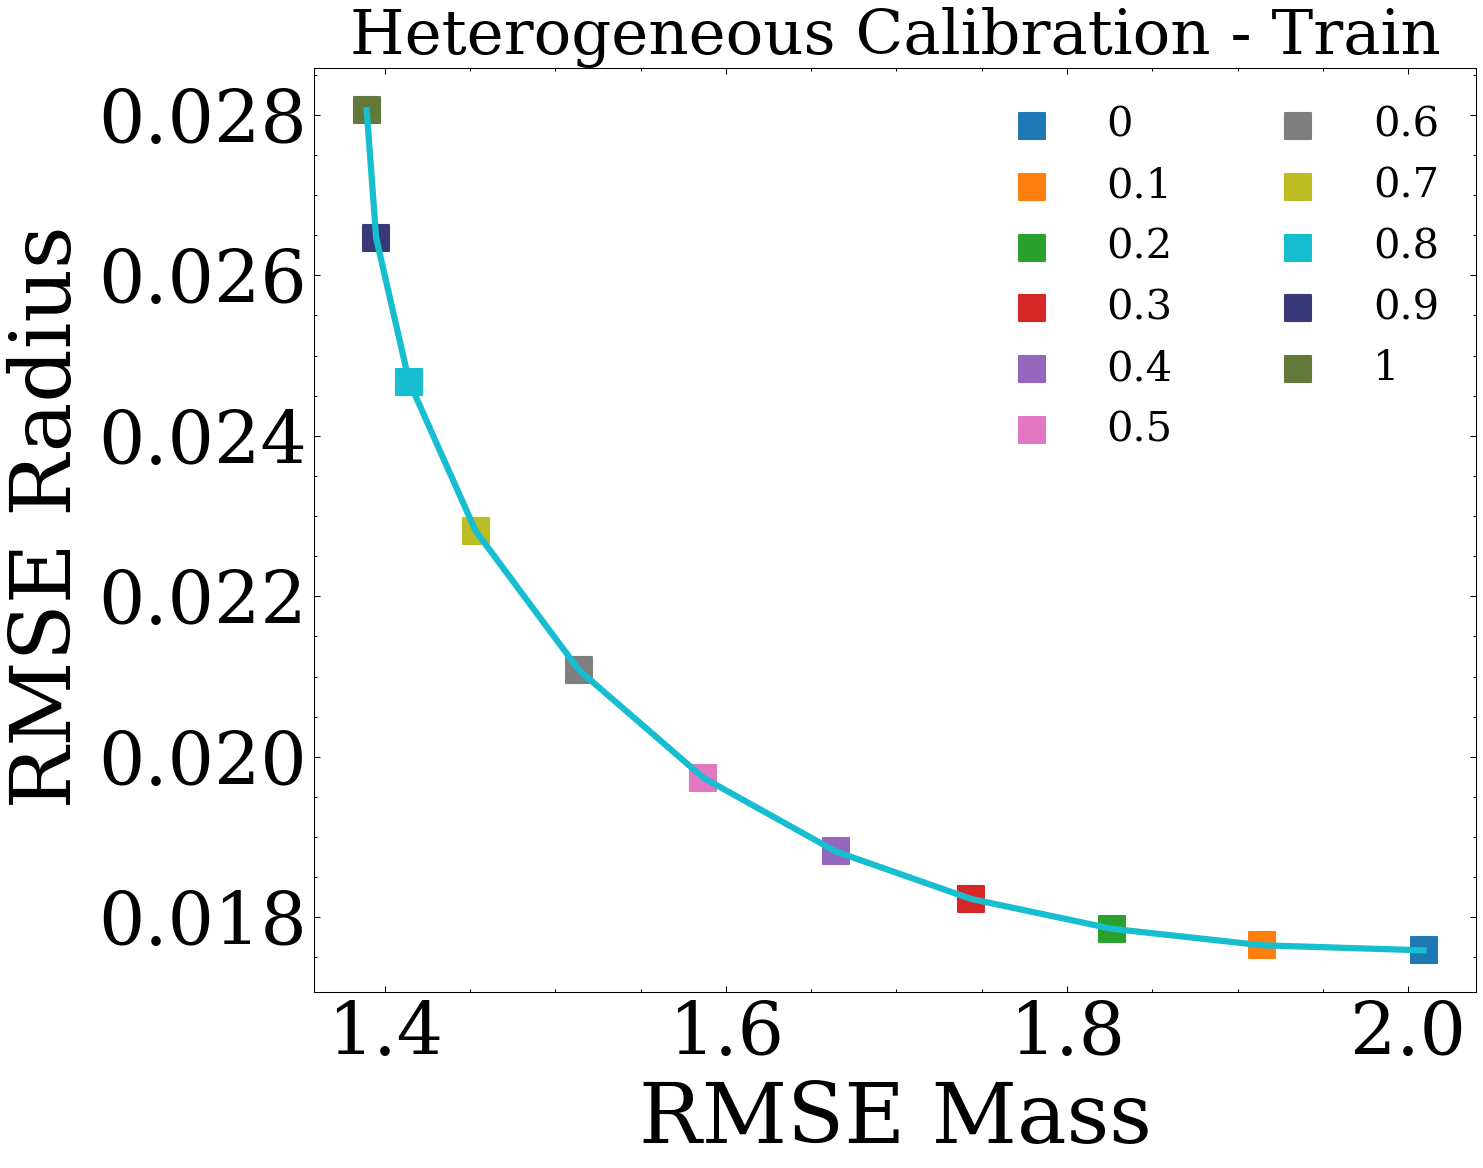

In [561]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150
for i in range(len(importance)):
    ax.scatter(mass_std*weighted_RMSE_mass_matrix[i,0],radius_std*weighted_RMSE_radius_matrix[i,0] ,color=colors[i],s=size_points,marker=marker_train, label = p[i])
    
ax.plot(mass_std*weighted_RMSE_mass_matrix[:,0], radius_std*weighted_RMSE_radius_matrix[:,0],color=color_train,linewidth=3)

# ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
# ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'RMSE Mass',fontsize=40)
ax.set_ylabel(r' RMSE Radius',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(0, 0.03)
# plt.xlim(1,2.2)
plt.title('Heterogeneous Calibration - Train', fontsize = 30)
# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.legend(fontsize=20, ncols = 2)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE BE vs CR - weight imposed likelihood/RMSE comparison - training region - 2PCs.png')
plt.show()

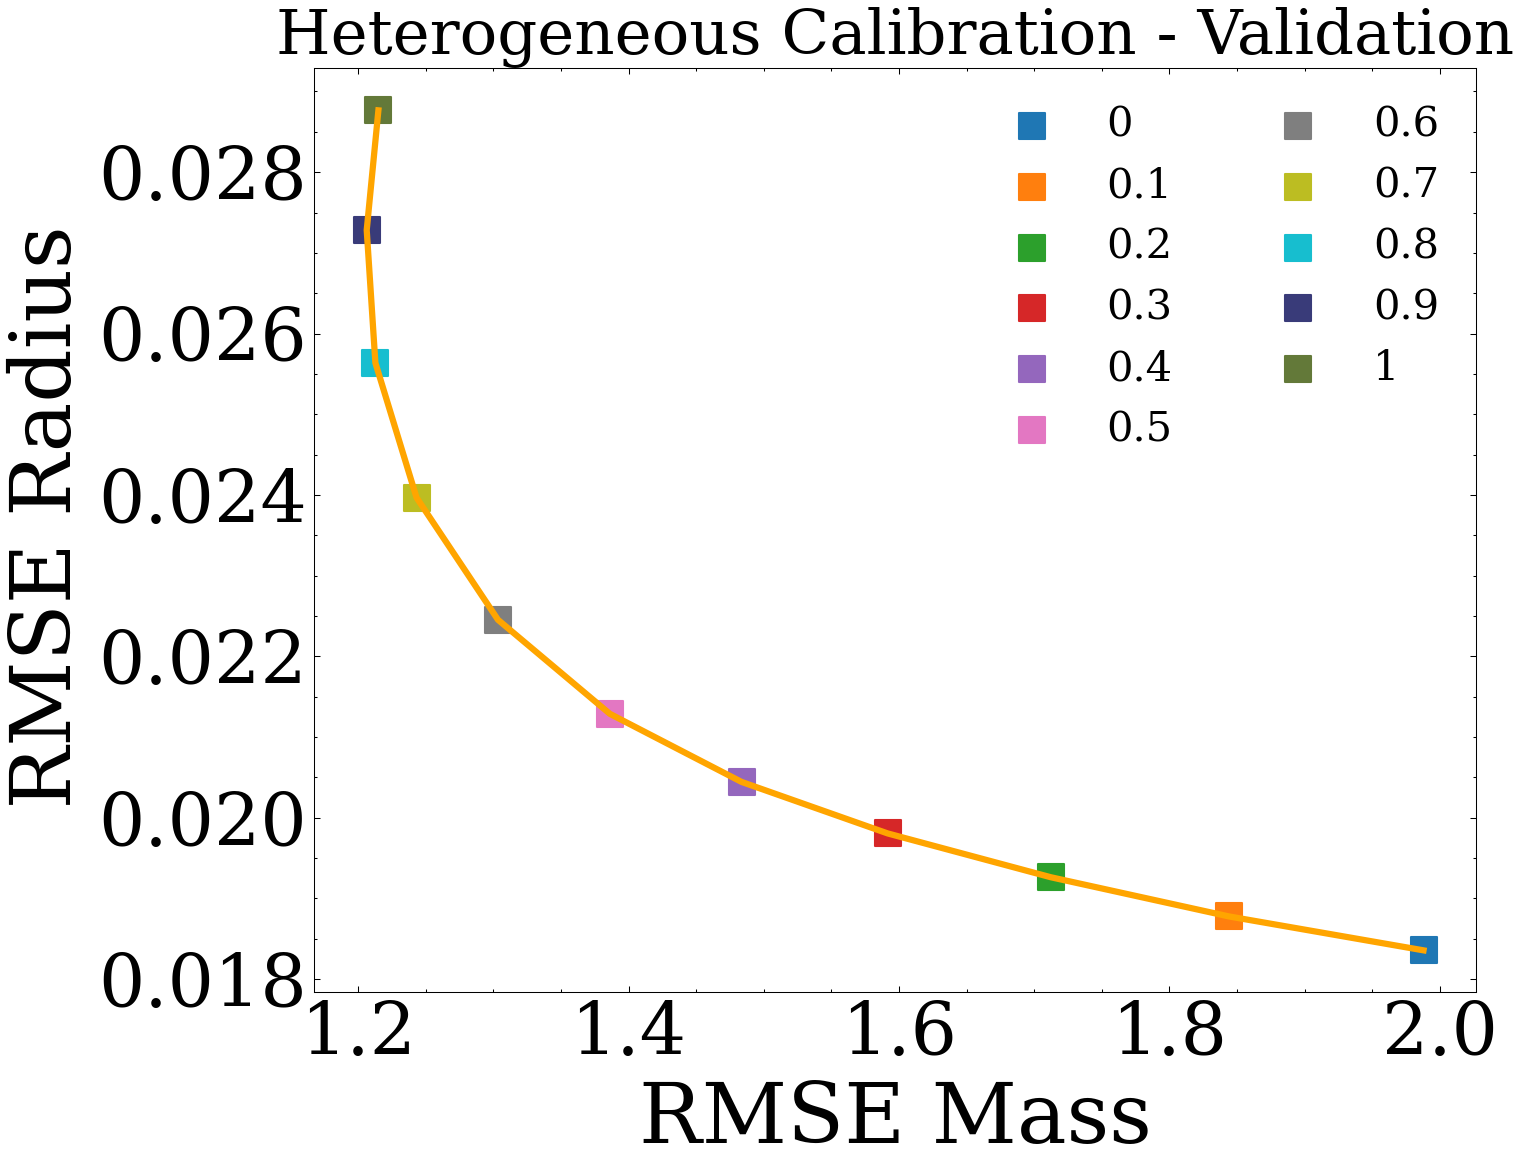

In [562]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150
for i in range(len(importance)):
    ax.scatter(mass_std*weighted_RMSE_mass_matrix[i,1],radius_std*weighted_RMSE_radius_matrix[i,1] ,color=colors[i],s=size_points,marker=marker_train, label = p[i])
    
ax.plot(mass_std*weighted_RMSE_mass_matrix[:,1], radius_std*weighted_RMSE_radius_matrix[:,1],color=color_validation,linewidth=3)

# ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
# ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'RMSE Mass',fontsize=40)
ax.set_ylabel(r' RMSE Radius',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)
plt.title('Heterogeneous Calibration - Validation', fontsize = 30)
# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.legend(fontsize=20, ncols = 2)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE BE vs CR - weight imposed likelihood/RMSE comparison - validation region - 2PCs.png')
plt.show()

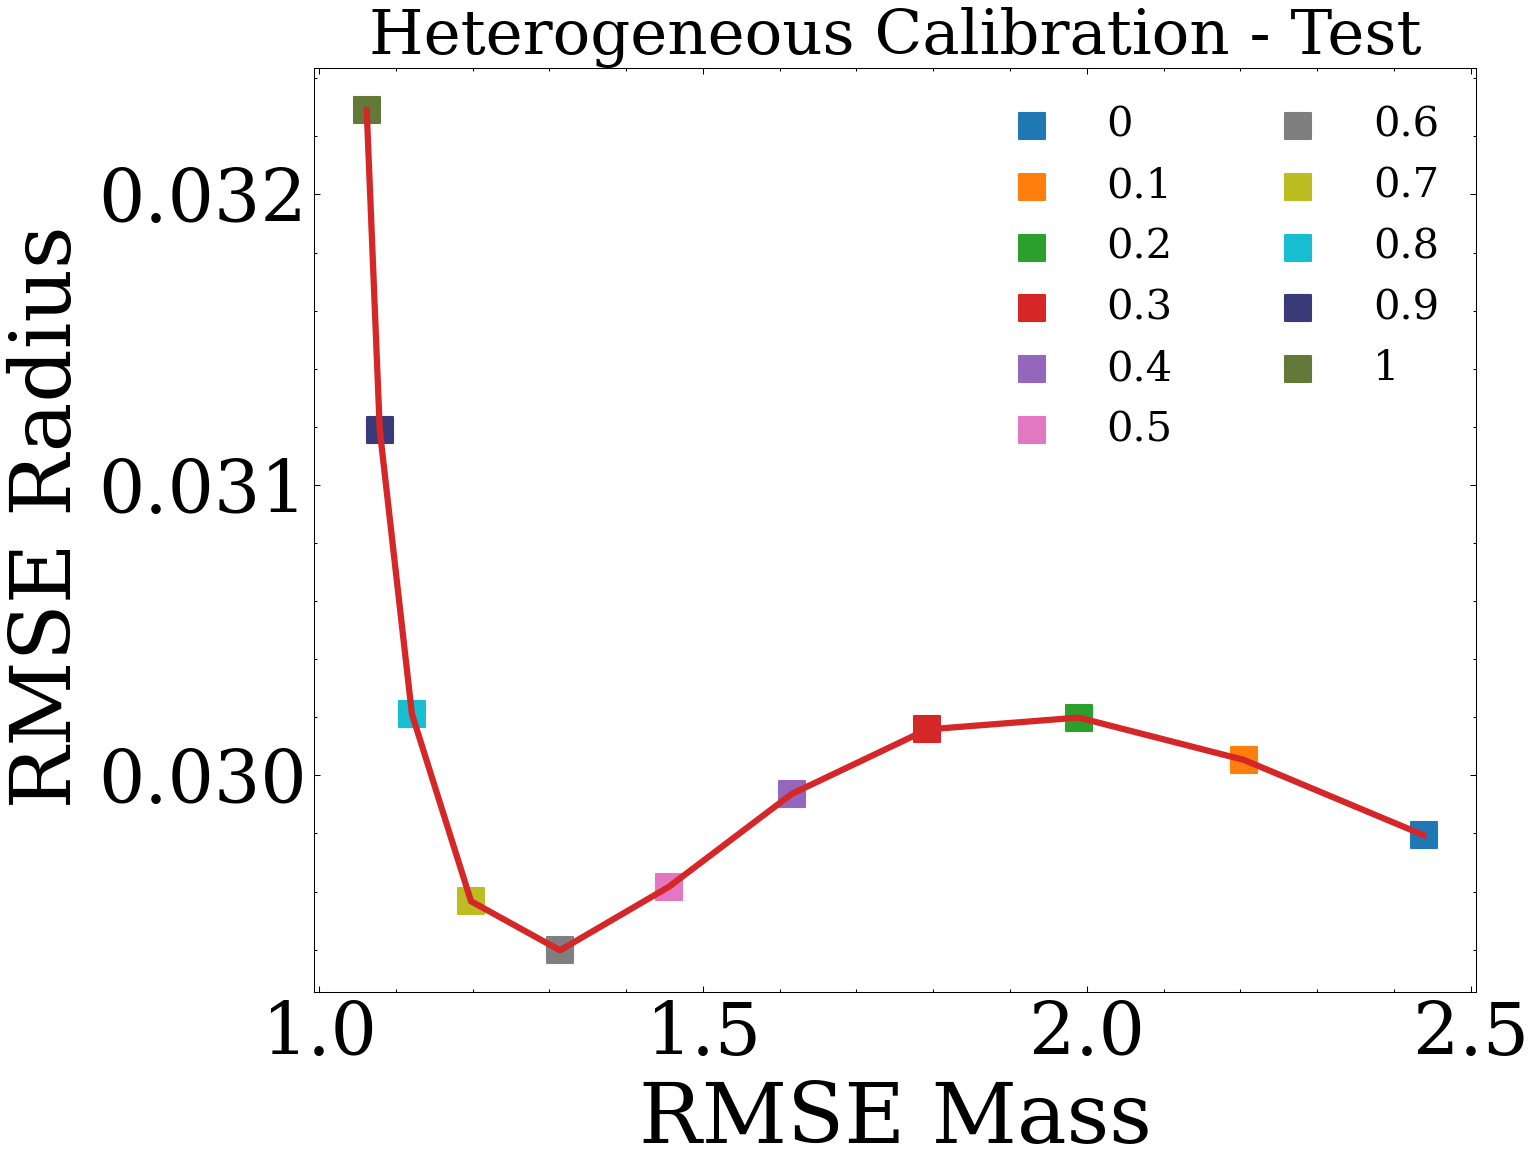

In [563]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150
for i in range(len(importance)):
    ax.scatter(mass_std*weighted_RMSE_mass_matrix[i,2],radius_std*weighted_RMSE_radius_matrix[i,2] ,color=colors[i],s=size_points,marker=marker_train, label = p[i])
    
ax.plot(mass_std*weighted_RMSE_mass_matrix[:,2],radius_std* weighted_RMSE_radius_matrix[:,2],color=color_test,linewidth=3)

# ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
# ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'RMSE Mass',fontsize=40)
ax.set_ylabel(r' RMSE Radius',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)
plt.title('Heterogeneous Calibration - Test', fontsize = 30)
# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.legend(fontsize=20, ncols = 2)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE BE vs CR - weight imposed likelihood/RMSE comparison - testing region - 2PCs.png')
plt.show()